<a href="https://colab.research.google.com/github/Naduli48/Book_store/blob/main/TUT2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json, os, pickle, joblib

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from scipy.stats.mstats import winsorize
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet

!pip install wbgapi prophet shap lime
import wbgapi as wb

from google.colab import drive
drive.mount('/content/drive')

SAVE_DIR  = './output/'
DRIVE_DIR = '/content/drive/MyDrive/SDGP'
os.makedirs(SAVE_DIR,  exist_ok=True)
os.makedirs(DRIVE_DIR, exist_ok=True)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 13.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=d19af266c424a452db24870ead90d9921280b6346108782f8908cc392092562a
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime
Mounted at /content/drive


In [3]:
# ============================================================
# SECTION 1: LOAD BOTH DATASETS
# ============================================================
# --- 1A: final_new1 — rich features (BMI, age, risk, premium, frequency) ---
df1 = pd.read_excel('/content/drive/MyDrive/SDGP/final_new1.xlsx')
print("final_new1 raw shape:", df1.shape)

# --- 1B: combined_df — broader claim records, extends time series to 2026 ---
df2_raw = pd.read_excel('/content/drive/MyDrive/SDGP/combined_df.xlsx')
print("combined_df raw shape:", df2_raw.shape)

df2_raw = df2_raw.rename(columns={
    "NVL(C.POLICYNO,'N/A')": 'policy_id',
    "NVL(C.CLAIMNO,'N/A')":  'claim_id',
    'SETTLEDDATE':            'claim_settled_date',
    'CLAIMAMOUNT':            'PaidAmount_combined',
    'STATUS':                 'claim_status_combined',
})
df2_raw['claim_settled_date'] = pd.to_datetime(
    df2_raw['claim_settled_date'], format='%d-%b-%y', errors='coerce'
)
df2_raw = df2_raw[df2_raw['claim_settled_date'] <= pd.Timestamp.today()]

# Deduplicate combined_df by policy+claim
df2 = df2_raw.groupby(['policy_id', 'claim_id']).agg(
    PaidAmount_combined   = ('PaidAmount_combined',  'sum'),
    claim_settled_date    = ('claim_settled_date',   'first'),
    claim_status_combined = ('claim_status_combined','first'),
    SUMINSURED            = ('SUMINSURED',           'first'),
).reset_index()
print(f"combined_df after dedup: {df2.shape}")

df = df1.copy()

final_new1 raw shape: (10651, 117)
combined_df raw shape: (28135, 10)
combined_df after dedup: (5076, 6)


In [4]:
# ============================================================
# SECTION 2: DIAGNOSTIC — ROW DROP EXPLANATION
# ============================================================
print("\n=== DIAGNOSTIC: Understanding the row drop ===")
print(f"Total raw rows in final_new1      : {len(df)}")
print(f"Unique policy_id                   : {df['policy_id'].nunique()}")
print(f"Unique claim_id                    : {df['claim_id'].nunique()}")
dup_counts = df.groupby(['policy_id', 'claim_id']).size()
print(f"Max rows per (policy_id + claim_id): {dup_counts.max()}")
print(f"Rows that will be collapsed        : {(dup_counts - 1).sum()}")
print(f"Expected rows after dedup          : {dup_counts.shape[0]}")
print(f"Null claim_settled_date            : {df['claim_settled_date'].isna().sum()}")
print("\nWHY: One claim can pay multiple benefit types (hospital + accident + critical illness)")
print("     Each benefit type = one row in the database with same policy_id + claim_id")
print("     Dedup collapses them into 1 row by summing PaidAmount → CORRECT, not data loss")


=== DIAGNOSTIC: Understanding the row drop ===
Total raw rows in final_new1      : 10651
Unique policy_id                   : 2445
Unique claim_id                    : 4667
Max rows per (policy_id + claim_id): 36
Rows that will be collapsed        : 5984
Expected rows after dedup          : 4667
Null claim_settled_date            : 2

WHY: One claim can pay multiple benefit types (hospital + accident + critical illness)
     Each benefit type = one row in the database with same policy_id + claim_id
     Dedup collapses them into 1 row by summing PaidAmount → CORRECT, not data loss


In [5]:
# ============================================================
# SECTION 3: DROP QID COLUMNS
# ============================================================
qid_cols = [col for col in df.columns if col.startswith("QID_")]
df.drop(columns=qid_cols, inplace=True)
print(f"\nDropped {len(qid_cols)} QID columns. Shape: {df.shape}")


Dropped 11 QID columns. Shape: (10651, 106)


In [6]:
# ============================================================
# SECTION 4: PAYMENT FREQUENCY ENCODING
# ============================================================
freq_letter_to_periods = {'M': 12, 'A': 1, 'Q': 4, 'H': 2, 'S': 2, 'Unknown': np.nan}
df['payment_periods_per_year'] = df['payment_frequency'].map(freq_letter_to_periods)

freq_x_map = {12.0: 12, 1.0: 1, 4.0: 4, 2.0: 2, 0.0: np.nan}
df['payment_periods_from_x'] = df['PaymentFrequency_x'].map(freq_x_map)
df['payment_periods_per_year'] = df['payment_periods_per_year'].fillna(df['payment_periods_from_x'])
df.drop(columns=['payment_periods_from_x'], inplace=True)

periods_to_label = {1: 'Annual', 2: 'Half-Yearly', 4: 'Quarterly', 12: 'Monthly'}
df['payment_freq_label'] = df['payment_periods_per_year'].map(periods_to_label).fillna('Unknown')

print("\n=== Payment Frequency Distribution ===")
print(df['payment_freq_label'].value_counts())



=== Payment Frequency Distribution ===
payment_freq_label
Monthly        7334
Annual         2166
Quarterly       659
Half-Yearly     483
Unknown           9
Name: count, dtype: int64


In [7]:
# ============================================================
# SECTION 5: ANNUAL PREMIUM CALCULATION
# ============================================================
df['annual_premium'] = df['PREMIUMAMOUNT_x'].replace(0, np.nan)
df['annual_premium'] = df['annual_premium'].fillna(df['PREMIUMAMOUNT_y'])
df['annual_premium'] = df['annual_premium'].fillna(df['Premium'] * df['payment_periods_per_year'])
df['annual_premium'] = df['annual_premium'].fillna(df['premium_amount'])

print("\n=== Annual Premium Stats ===")
print(df['annual_premium'].describe())


=== Annual Premium Stats ===
count    1.065100e+04
mean     6.746338e+04
std      1.353751e+05
min      0.000000e+00
25%      9.991500e+03
50%      1.778300e+04
75%      5.801150e+04
max      1.499789e+06
Name: annual_premium, dtype: float64


In [8]:
# ============================================================
# SECTION 6: ACTIVE POLICY FLAG
# OPEN + PDUP = active; LAPSE, SURD, DEATH, SPCRV, TPDSK, CEASE = inactive
# ============================================================
ACTIVE_STATUSES = ['OPEN', 'PDUP']
df['is_active_policy'] = df['STATUS_y'].isin(ACTIVE_STATUSES).astype(int)

status_category_map = {
    'OPEN': 'Active', 'PDUP': 'Active',
    'LAPSE': 'Lapsed', 'SPCRV': 'Surrendered', 'SURD': 'Surrendered',
    'DEATH': 'Death_Claim', 'TPDSK': 'Disability', 'CEASE': 'Ceased',
}
df['policy_status_category'] = df['STATUS_y'].map(status_category_map).fillna('Other')
df["policy_status"] = df["STATUS_y"].fillna("Unknown")

print("\n=== Policy Status Breakdown ===")
print(df['policy_status_category'].value_counts())


=== Policy Status Breakdown ===
policy_status_category
Active         7505
Lapsed         1921
Surrendered     668
Other           346
Death_Claim     200
Disability       10
Ceased            1
Name: count, dtype: int64


In [9]:
# ============================================================
# SECTION 7: DEDUPLICATE & AGGREGATE
# ============================================================
aggregation_dict = {
    'PaidAmount_x':            'sum',
    'annual_premium':          'mean',
    'Premium':                 'mean',
    'Age':                     'mean',
    'BMI':                     'mean',
    'IsSmoker':                'first',
    'IsAlcoholic':             'first',
    'total_lifestyle_risk':    'mean',
    'risk_bucket':             'first',
    'STATUS_y':                'first',
    'policy_status_category':  'first',
    'policy_status':           'first',
    'is_active_policy':        'first',
    'claim_settled_date':      'first',
    'payment_freq_label':      'first',
    'payment_periods_per_year':'mean',
}
for opt_col in ['TotalSumAssured', 'MonthlyIncome', 'Gender', 'District',
                'sum_insured', 'foreign_sum_insured']:
    if opt_col in df.columns:
        aggregation_dict[opt_col] = 'first'

before_dedup = len(df)
df = df.groupby(['policy_id', 'claim_id']).agg(aggregation_dict).reset_index()
print(f"\nBefore dedup : {before_dedup} rows")
print(f"After dedup  : {df.shape[0]} rows")
print(f"Collapsed    : {before_dedup - df.shape[0]} rows (these were duplicate benefit rows, not data loss)")


Before dedup : 10651 rows
After dedup  : 4667 rows
Collapsed    : 5984 rows (these were duplicate benefit rows, not data loss)


In [10]:
# ============================================================
# SECTION 8: HANDLE DATES
# ============================================================
df["claim_settled_date"] = pd.to_datetime(df["claim_settled_date"], errors="coerce")
before_date = len(df)
df = df.dropna(subset=["claim_settled_date"])
print(f"\nDate cleaning: dropped {before_date - len(df)} null-date rows → {len(df)} rows remain")
df["claim_month"] = df["claim_settled_date"].dt.to_period("M").dt.to_timestamp()


Date cleaning: dropped 1 null-date rows → 4666 rows remain


In [11]:
# ============================================================
# SECTION 9: MISSING VALUE IMPUTATION
# ============================================================
impute_cols = [col for col in ["BMI", "Age", "MonthlyIncome", "annual_premium",
                                "payment_periods_per_year"] if col in df.columns]
knn_imputer = KNNImputer(n_neighbors=5)
df[impute_cols] = knn_imputer.fit_transform(df[impute_cols])

for col in ['IsSmoker', 'IsAlcoholic']:
    if col in df.columns:
        df[col] = df[col].replace({'Yes': 1, 'No': 0, 'Unknown': 0}).fillna(0).astype(int)

text_cols = ["NVL(C.REMARKS,'N/A')", "NVL(C.REJECTIONREMARKS,'N/A')",
             "ChildUnderMedication", "OccupationCode", "MaritalStatus",
             "District", "JIC", "OtherCompany"]
for col in text_cols:
    if col in df.columns:
        df[col] = df[col].fillna("Not Available")

zero_fill_cols = ["DependentCount", "PolicyCount", "Total_LB", "Prospect_Monthly", "Spouse_Monthly"]
for col in zero_fill_cols:
    if col in df.columns:
        df[col] = df[col].fillna(0)

/tmp/ipykernel_15318/3138020269.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace({'Yes': 1, 'No': 0, 'Unknown': 0}).fillna(0).astype(int)
/tmp/ipykernel_15318/3138020269.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace({'Yes': 1, 'No': 0, 'Unknown': 0}).fillna(0).astype(int)


In [12]:
# ============================================================
# SECTION 10: FEATURE ENGINEERING
# ============================================================
df['weighted_lifestyle_risk'] = (df['IsSmoker'] * 5.0) + (df['IsAlcoholic'] * 3.0)
df['is_high_risk_profile']    = ((df['IsSmoker'] == 1) | (df['IsAlcoholic'] == 1)).astype(int)
df['lifestyle_flag']          = df['is_high_risk_profile'].copy()

df["final_claim_amount"] = np.log1p(df["PaidAmount_x"].fillna(0))
upper_limit = df["final_claim_amount"].quantile(0.99)
df["final_claim_amount"] = df["final_claim_amount"].clip(upper=upper_limit)

df["profit_proxy"] = df["annual_premium"] / (df["PaidAmount_x"].replace(0, np.nan))

df = df.sort_values(["policy_id", "claim_settled_date"])
df["policy_claim_count"] = df.groupby("policy_id")["claim_id"].transform("count")
df["policy_total_claim"] = df.groupby("policy_id")["final_claim_amount"].transform("sum")
df["policy_avg_claim"]   = (df["policy_total_claim"] / df["policy_claim_count"]).fillna(0)

df['is_monthly_payer']   = (df['payment_periods_per_year'] == 12).astype(int)
df['is_annual_payer']    = (df['payment_periods_per_year'] == 1).astype(int)
df['is_quarterly_payer'] = (df['payment_periods_per_year'] == 4).astype(int)

print(f"\nFeature engineering complete. Shape: {df.shape}")
df.head()
df.to_excel(f'{DRIVE_DIR}/new_down.xlsx', index=False)


Feature engineering complete. Shape: (4666, 36)


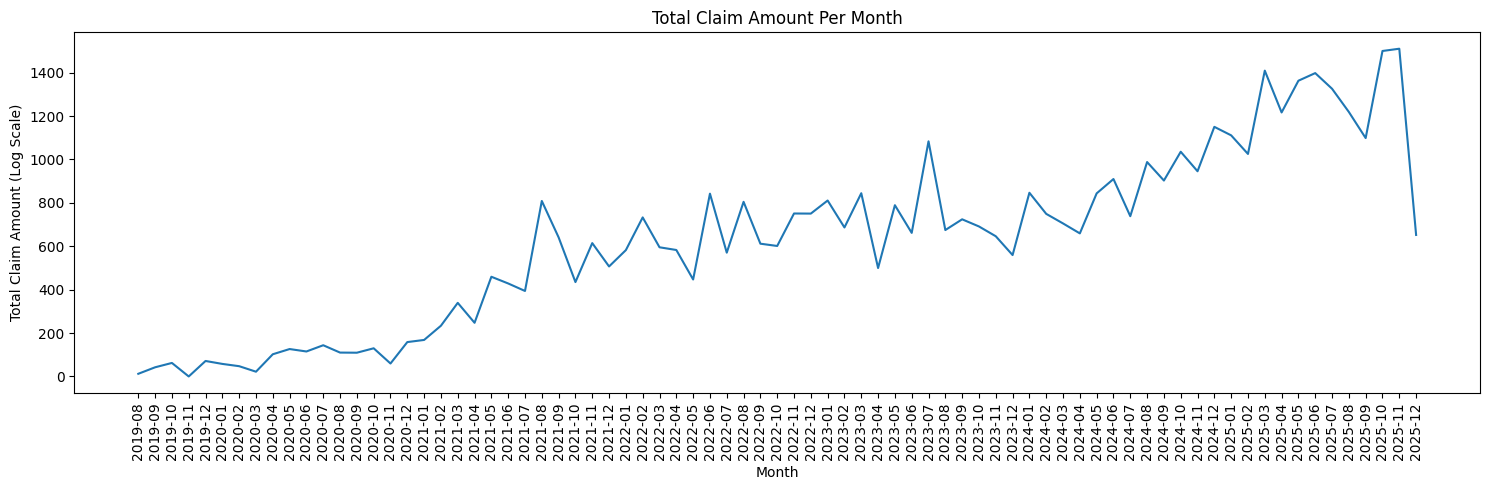

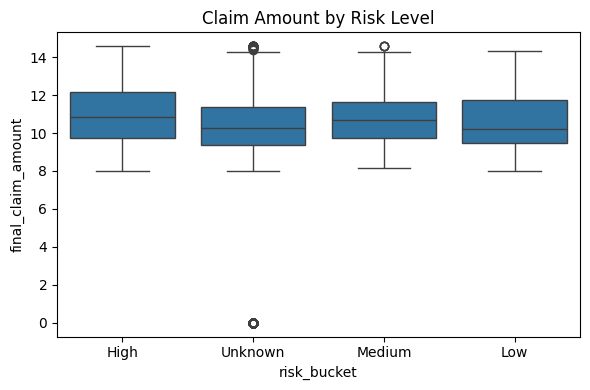

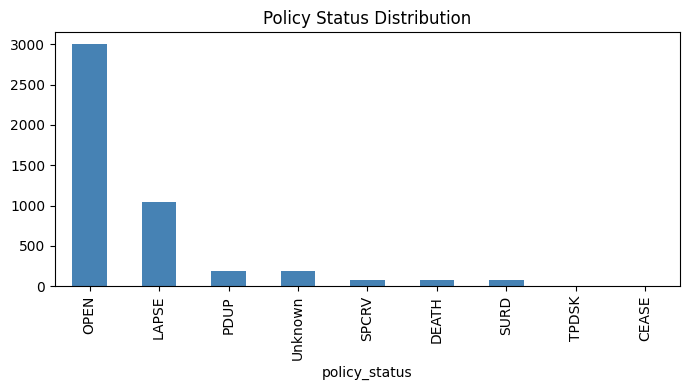

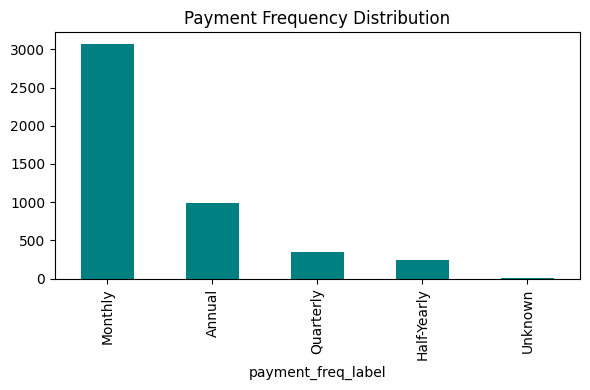

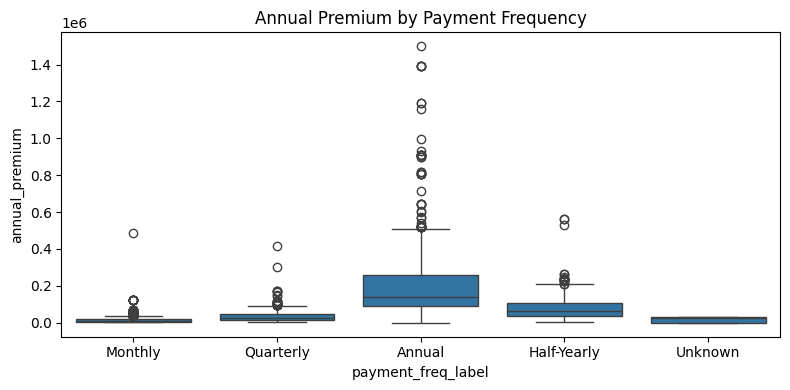

In [13]:
# ============================================================
# SECTION 11: EDA — KEY CHARTS
# ============================================================
# Chart 1: Claims over time
monthly_plot = (
    df.groupby(df["claim_settled_date"].dt.to_period("M"))["final_claim_amount"]
      .sum().reset_index()
)
monthly_plot["claim_settled_date"] = monthly_plot["claim_settled_date"].astype(str)

plt.figure(figsize=(15, 5))
plt.plot(monthly_plot["claim_settled_date"], monthly_plot["final_claim_amount"])
plt.xticks(rotation=90)
plt.title("Total Claim Amount Per Month")
plt.xlabel("Month")
plt.ylabel("Total Claim Amount (Log Scale)")
plt.tight_layout()
plt.savefig(SAVE_DIR + "kpi_claim_trend.png", dpi=150, bbox_inches='tight')
plt.show()

# Chart 2: Claim by risk bucket
plt.figure(figsize=(6, 4))
sns.boxplot(x="risk_bucket", y="final_claim_amount", data=df)
plt.title("Claim Amount by Risk Level")
plt.tight_layout()
plt.savefig(SAVE_DIR + "kpi_risk_vs_claim.png", dpi=150, bbox_inches='tight')
plt.show()

# Chart 3: Policy status distribution
plt.figure(figsize=(7, 4))
df["policy_status"].value_counts().plot(kind="bar", color='steelblue')
plt.title("Policy Status Distribution")
plt.tight_layout()
plt.savefig(SAVE_DIR + "kpi_policy_status.png", dpi=150, bbox_inches='tight')
plt.show()

# Chart 4: Payment frequency distribution
plt.figure(figsize=(6, 4))
df['payment_freq_label'].value_counts().plot(kind='bar', color='teal')
plt.title("Payment Frequency Distribution")
plt.tight_layout()
plt.savefig(SAVE_DIR + "kpi_payment_freq.png", dpi=150, bbox_inches='tight')
plt.show()

# Chart 5: Annual premium distribution by payment frequency
plt.figure(figsize=(8, 4))
sns.boxplot(x='payment_freq_label', y='annual_premium', data=df)
plt.title("Annual Premium by Payment Frequency")
plt.tight_layout()
plt.savefig(SAVE_DIR + "kpi_premium_by_freq.png", dpi=150, bbox_inches='tight')
plt.show()

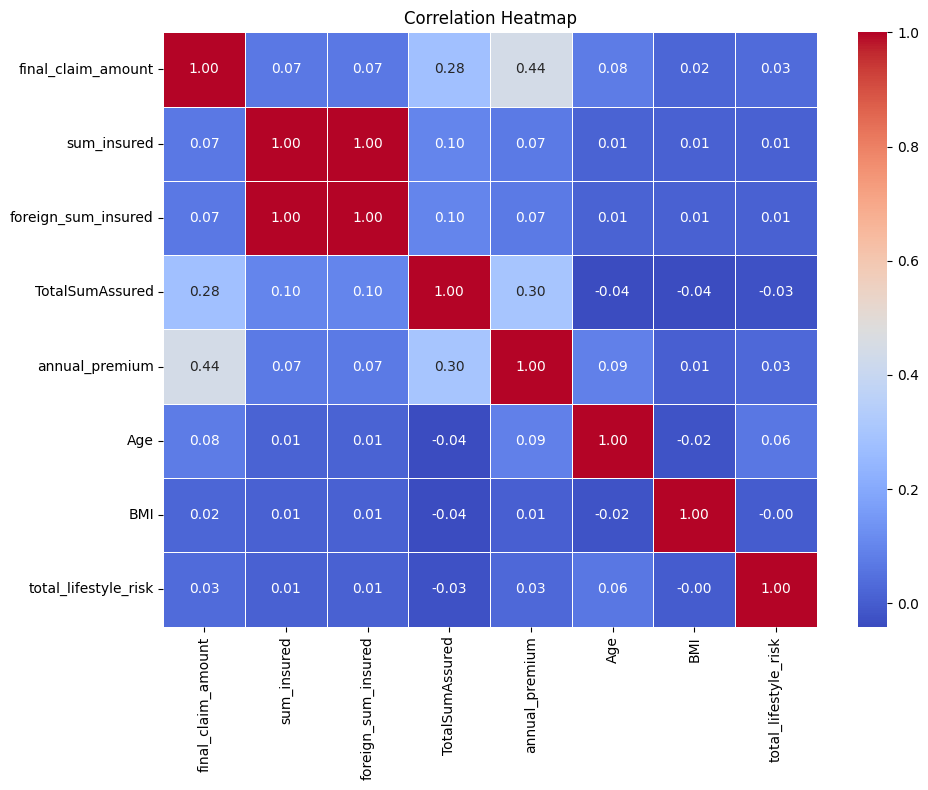

PCA components: 2


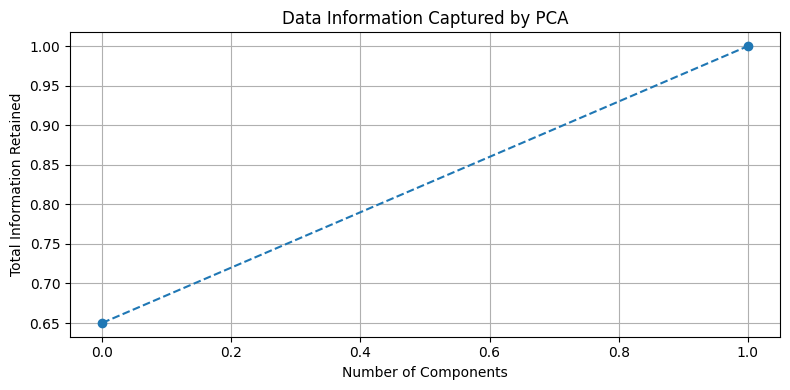

PCA Regression MAE: 1.1057217812747895


In [14]:
# ============================================================
# SECTION 12: CORRELATION & PCA
# ============================================================
corr_features = ["final_claim_amount", "sum_insured", "foreign_sum_insured",
                 "TotalSumAssured", "annual_premium", "Age", "BMI", "total_lifestyle_risk"]
corr_features = [col for col in corr_features if col in df.columns]
corr_matrix   = df[corr_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig(SAVE_DIR + "kpi_correlation.png", dpi=150, bbox_inches='tight')
plt.show()

corr_target       = df[corr_features].corr()['final_claim_amount'].abs()
selected_features = corr_target[corr_target > 0.10].index.tolist()

pca_features    = df[selected_features].drop(columns=['final_claim_amount'])
scaler          = StandardScaler()
scaled_features = scaler.fit_transform(pca_features.fillna(0))

pca            = PCA(n_components=0.90)
pca_components = pca.fit_transform(scaled_features)
print("PCA components:", pca.n_components_)

for i in range(pca.n_components_):
    df[f'PCA_{i+1}'] = pca_components[:, i]

plt.figure(figsize=(8, 4))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o', linestyle='--')
plt.title("Data Information Captured by PCA")
plt.xlabel("Number of Components")
plt.ylabel("Total Information Retained")
plt.grid()
plt.tight_layout()
plt.savefig(SAVE_DIR + "kpi_pca.png", dpi=150, bbox_inches='tight')
plt.show()

# PCA regression validation
pca_cols = [col for col in df.columns if col.startswith("PCA_")]
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    df[pca_cols], df["final_claim_amount"], test_size=0.2, shuffle=False
)
lr = LinearRegression()
lr.fit(X_train_pca, y_train_pca)
print("PCA Regression MAE:", mean_absolute_error(y_test_pca, lr.predict(X_test_pca)))

# Correlation: save for app
corr_export = df[corr_features].corr().reset_index()
corr_export.to_csv(f"{DRIVE_DIR}/kpi_correlation.csv", index=False)

Time series: 80 months | 2019-08-01 00:00:00 → 2026-03-01 00:00:00


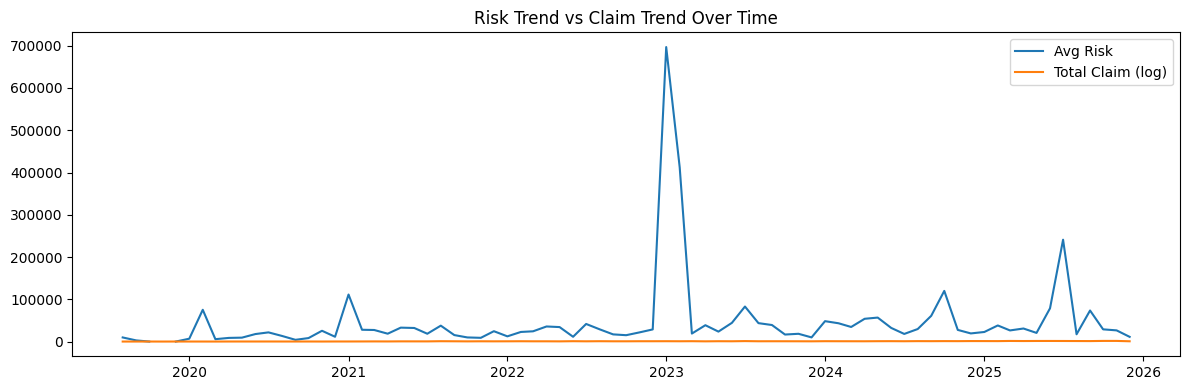

In [15]:
# ============================================================
# SECTION 13: MONTHLY TIME SERIES CONSTRUCTION
# combined_df = base for claim amounts (80 months, to 2026)
# final_new1  = source of monthly features (left-joined)
# ============================================================
df2['claim_month'] = df2['claim_settled_date'].dt.to_period('M').dt.to_timestamp()
monthly_actual_claims = df2.groupby('claim_month')['PaidAmount_combined'].sum().reset_index()
monthly_actual_claims = monthly_actual_claims.rename(columns={'PaidAmount_combined': 'PaidAmount_x'})
monthly_actual_claims = monthly_actual_claims[monthly_actual_claims['PaidAmount_x'] > 0]
monthly_actual_claims['total_claim_amount_original_scale'] = winsorize(
    monthly_actual_claims['PaidAmount_x'], limits=[0, 0.01]
)
monthly_actual_claims['total_claim_amount'] = np.log1p(
    monthly_actual_claims['total_claim_amount_original_scale']
)

monthly_features = df.groupby('claim_month').agg(
    avg_annual_premium       = ('annual_premium',            'mean'),
    avg_lifestyle_risk       = ('weighted_lifestyle_risk',   'mean'),
    high_risk_claimant_count = ('is_high_risk_profile',      'sum'),
    avg_bmi                  = ('BMI',                       'mean'),
    avg_age                  = ('Age',                       'mean'),
    policy_count             = ('policy_id',                 'nunique'),
    active_policy_count      = ('is_active_policy',          'sum'),
    active_policy_ratio      = ('is_active_policy',          'mean'),
    avg_claim_history        = ('policy_avg_claim',          'mean'),
    monthly_payer_ratio      = ('is_monthly_payer',          'mean'),
    quarterly_payer_ratio    = ('is_quarterly_payer',        'mean'),
    annual_payer_ratio       = ('is_annual_payer',           'mean'),
    high_risk_pct            = ('is_high_risk_profile',      'mean'),
).reset_index()

monthly_actual_claims['claim_month'] = pd.to_datetime(monthly_actual_claims['claim_month'])
monthly_features['claim_month']      = pd.to_datetime(monthly_features['claim_month'])

ts_data = pd.merge(
    monthly_actual_claims, monthly_features, on="claim_month", how="left"
).sort_values("claim_month")

print(f"Time series: {len(ts_data)} months | {ts_data['claim_month'].min()} → {ts_data['claim_month'].max()}")

# Risk vs claim trend
monthly_risk_trend = df.groupby("claim_month").agg(
    avg_lifestyle_risk = ("total_lifestyle_risk", "mean"),
    total_claim        = ("final_claim_amount",   "sum")
).reset_index()

plt.figure(figsize=(12, 4))
plt.plot(monthly_risk_trend["claim_month"], monthly_risk_trend["avg_lifestyle_risk"], label="Avg Risk")
plt.plot(monthly_risk_trend["claim_month"], monthly_risk_trend["total_claim"],        label="Total Claim (log)")
plt.legend()
plt.title("Risk Trend vs Claim Trend Over Time")
plt.tight_layout()
plt.savefig(SAVE_DIR + "kpi_risk_trend.png", dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# ============================================================
# SECTION 14: EXTERNAL FACTORS
# ============================================================
try:
    wb_data        = wb.data.DataFrame('FP.CPI.TOTL.ZG', 'LKA', labels=True)
    real_inflation = wb_data.iloc[0, :].dropna().values[-1]
    ts_data["inflation_rate"] = np.linspace(real_inflation - 2, real_inflation + 2, len(ts_data))
    print(f"\nReal Sri Lanka inflation rate used: {real_inflation:.2f}%")
except Exception as e:
    print(f"World Bank API failed: {e}. Using fallback values.")
    ts_data["inflation_rate"] = np.linspace(4.5, 9.0, len(ts_data))

ts_data["interest_rate"]   = ts_data["inflation_rate"] * 0.7 + 1.5
ts_data["fx_impact_index"] = np.linspace(1.0, 1.4, len(ts_data))

ts_data.set_index("claim_month", inplace=True)
ts_data = ts_data.asfreq('MS')

# Forward-fill any NaN in features (for the 3 extra months from combined_df)
ts_data = ts_data.fillna(method='ffill')

ts_data['target_log'] = np.log1p(ts_data['total_claim_amount_original_scale'])
y = ts_data["target_log"]
print(f"Time series ready. Months: {len(ts_data)} | Max Y: {y.max():.2f}")


Real Sri Lanka inflation rate used: -0.43%
Time series ready. Months: 80 | Max Y: 18.84


/tmp/ipykernel_15318/1726090637.py:20: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  ts_data = ts_data.fillna(method='ffill')


In [17]:
# ============================================================
# SECTION 15: DEFINE REGRESSORS
# ============================================================
REGRESSOR_COLS = [
    'avg_annual_premium', 'avg_lifestyle_risk', 'high_risk_claimant_count',
    'avg_bmi', 'avg_age', 'policy_count', 'active_policy_count',
    'active_policy_ratio', 'avg_claim_history', 'monthly_payer_ratio',
    'quarterly_payer_ratio', 'annual_payer_ratio', 'high_risk_pct',
    'inflation_rate', 'interest_rate', 'fx_impact_index',
]
REGRESSOR_COLS = [c for c in REGRESSOR_COLS if c in ts_data.columns]
print(f"\nRegressors ({len(REGRESSOR_COLS)}): {REGRESSOR_COLS}")

ts_data[REGRESSOR_COLS] = ts_data[REGRESSOR_COLS].fillna(method='ffill').fillna(0)

scaler_exog = StandardScaler()
exog_scaled = pd.DataFrame(
    scaler_exog.fit_transform(ts_data[REGRESSOR_COLS]),
    index=ts_data.index,
    columns=REGRESSOR_COLS
)


Regressors (16): ['avg_annual_premium', 'avg_lifestyle_risk', 'high_risk_claimant_count', 'avg_bmi', 'avg_age', 'policy_count', 'active_policy_count', 'active_policy_ratio', 'avg_claim_history', 'monthly_payer_ratio', 'quarterly_payer_ratio', 'annual_payer_ratio', 'high_risk_pct', 'inflation_rate', 'interest_rate', 'fx_impact_index']


/tmp/ipykernel_15318/1071231206.py:14: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  ts_data[REGRESSOR_COLS] = ts_data[REGRESSOR_COLS].fillna(method='ffill').fillna(0)


In [18]:
# ============================================================
# SECTION 16: TRAIN / TEST SPLIT
# ============================================================
TRAIN_RATIO = 0.8
train_size  = int(len(ts_data) * TRAIN_RATIO)
test_size   = len(ts_data) - train_size

print(f"\n{'='*55}")
print(f"  TRAIN/TEST SPLIT")
print(f"{'='*55}")
print(f"  Total months  : {len(ts_data)}")
print(f"  TRAINING SET  : {train_size} months  ({ts_data.index[0].strftime('%b %Y')} → {ts_data.index[train_size-1].strftime('%b %Y')})")
print(f"  TESTING  SET  : {test_size} months  ({ts_data.index[train_size].strftime('%b %Y')} → {ts_data.index[-1].strftime('%b %Y')})")
print(f"{'='*55}\n")

y_train          = y.iloc[:train_size]
y_test           = y.iloc[train_size:]
exog_train       = exog_scaled.iloc[:train_size]
exog_test        = exog_scaled.iloc[train_size:]
actuals_train_rs = ts_data['total_claim_amount_original_scale'].iloc[:train_size]
actuals_test_rs  = ts_data['total_claim_amount_original_scale'].iloc[train_size:]


  TRAIN/TEST SPLIT
  Total months  : 80
  TRAINING SET  : 64 months  (Aug 2019 → Nov 2024)
  TESTING  SET  : 16 months  (Dec 2024 → Mar 2026)



  MODEL A: ARIMAX (ARIMA + External Regressors)

  [ARIMAX — TRAINING PHASE]
  Training on 64 months: Aug 2019 → Nov 2024
  [ARIMAX TRAINING] MAE: Rs.8,214,888.13 | Accuracy: 72.70%

  [ARIMAX — TESTING PHASE]
  Testing on 16 months: Dec 2024 → Mar 2026

  [ARIMAX TESTING RESULTS]
  MAE      : Rs. 47,078,588.09
  RMSE     : Rs. 52,886,549.86
  WAPE     : 48.72%
  Accuracy : 51.28%


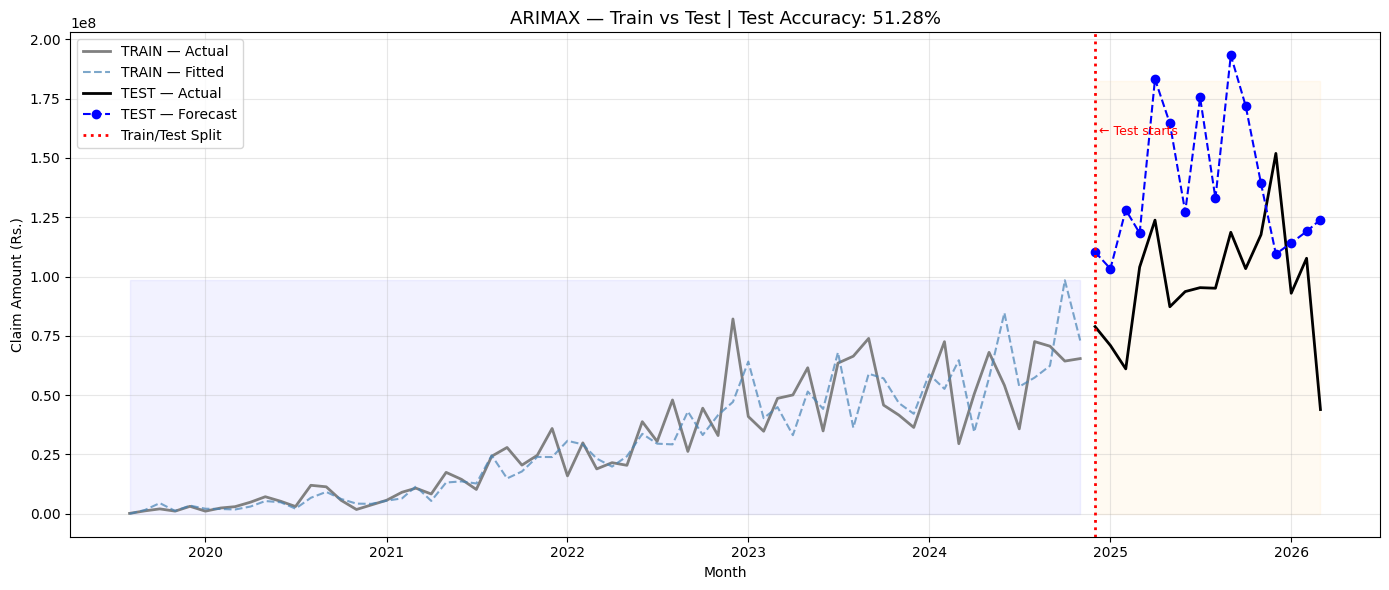

In [19]:
# ============================================================
# SECTION 17: MODEL A — ARIMAX
# ============================================================
print("=" * 60)
print("  MODEL A: ARIMAX (ARIMA + External Regressors)")
print("=" * 60)

# ─── TRAINING PHASE ───────────────────────────────────────────
print(f"\n  [ARIMAX — TRAINING PHASE]")
print(f"  Training on {train_size} months: {y_train.index[0].strftime('%b %Y')} → {y_train.index[-1].strftime('%b %Y')}")

arimax_model   = SARIMAX(y_train, exog=exog_train, order=(1, 1, 1),
                          enforce_stationarity=False, enforce_invertibility=False)
arimax_results = arimax_model.fit(disp=False, maxiter=2000)

arimax_train_log = arimax_results.fittedvalues
arimax_train_rs  = np.expm1(arimax_train_log)
arimax_train_mae  = np.mean(np.abs(actuals_train_rs - arimax_train_rs))
arimax_train_wape = (np.sum(np.abs(actuals_train_rs - arimax_train_rs)) / np.sum(actuals_train_rs)) * 100
arimax_train_acc  = max(0, 100 - arimax_train_wape)
print(f"  [ARIMAX TRAINING] MAE: Rs.{arimax_train_mae:,.2f} | Accuracy: {arimax_train_acc:.2f}%")

# ─── TESTING PHASE ────────────────────────────────────────────
print(f"\n  [ARIMAX — TESTING PHASE]")
print(f"  Testing on {test_size} months: {y_test.index[0].strftime('%b %Y')} → {y_test.index[-1].strftime('%b %Y')}")

arimax_test_log = arimax_results.predict(start=y_test.index[0], end=y_test.index[-1], exog=exog_test)
arimax_test_rs  = np.expm1(arimax_test_log)
arimax_mae      = np.mean(np.abs(actuals_test_rs - arimax_test_rs))
arimax_rmse     = np.sqrt(np.mean((actuals_test_rs - arimax_test_rs) ** 2))
arimax_wape     = (np.sum(np.abs(actuals_test_rs - arimax_test_rs)) / np.sum(actuals_test_rs)) * 100
arimax_acc      = max(0, 100 - arimax_wape)

print(f"\n  [ARIMAX TESTING RESULTS]")
print(f"  MAE      : Rs. {arimax_mae:,.2f}")
print(f"  RMSE     : Rs. {arimax_rmse:,.2f}")
print(f"  WAPE     : {arimax_wape:.2f}%")
print(f"  Accuracy : {arimax_acc:.2f}%")

# ARIMAX Plot — Train and Test clearly shown
plt.figure(figsize=(14, 6))
plt.fill_betweenx([0, actuals_train_rs.max() * 1.2],
                  actuals_train_rs.index[0], actuals_train_rs.index[-1],
                  alpha=0.05, color='blue')
plt.fill_betweenx([0, actuals_test_rs.max() * 1.2],
                  actuals_test_rs.index[0], actuals_test_rs.index[-1],
                  alpha=0.05, color='orange')
plt.plot(actuals_train_rs.index, actuals_train_rs.values, label="TRAIN — Actual",  color="gray",     linewidth=2)
plt.plot(arimax_train_rs.index,  arimax_train_rs.values,  label="TRAIN — Fitted",  color="steelblue",linestyle="--", alpha=0.7)
plt.plot(actuals_test_rs.index,  actuals_test_rs.values,  label="TEST — Actual",   color="black",    linewidth=2)
plt.plot(arimax_test_rs.index,   arimax_test_rs.values,   label="TEST — Forecast", color="blue",     linestyle="--", marker='o')
plt.axvline(x=y_test.index[0], color='red', linestyle=':', linewidth=2, label="Train/Test Split")
plt.text(y_test.index[0], actuals_test_rs.max() * 1.05, ' ← Test starts', color='red', fontsize=9)
plt.legend(loc='upper left')
plt.title(f"ARIMAX — Train vs Test | Test Accuracy: {arimax_acc:.2f}%", fontsize=13)
plt.xlabel("Month"); plt.ylabel("Claim Amount (Rs.)")
plt.grid(True, alpha=0.3); plt.tight_layout()
plt.savefig(SAVE_DIR + "arimax_train_test.png", dpi=150)
plt.savefig(DRIVE_DIR + "/arimax_forecast.png", dpi=150)
plt.show()


  MODEL B: PROPHET (with all regressors)

  [PROPHET — TRAINING PHASE]
  Training on 64 months: Aug 2019 → Nov 2024
  [PROPHET TRAINING] MAE: Rs.7,342,917.21 | Accuracy: 75.60%

  [PROPHET — TESTING PHASE]
  Testing on 16 months: Dec 2024 → Mar 2026

  [PROPHET TESTING RESULTS]
  MAE      : Rs. 22,825,436.31
  RMSE     : Rs. 28,659,068.57
  WAPE     : 23.62%
  Accuracy : 76.38%


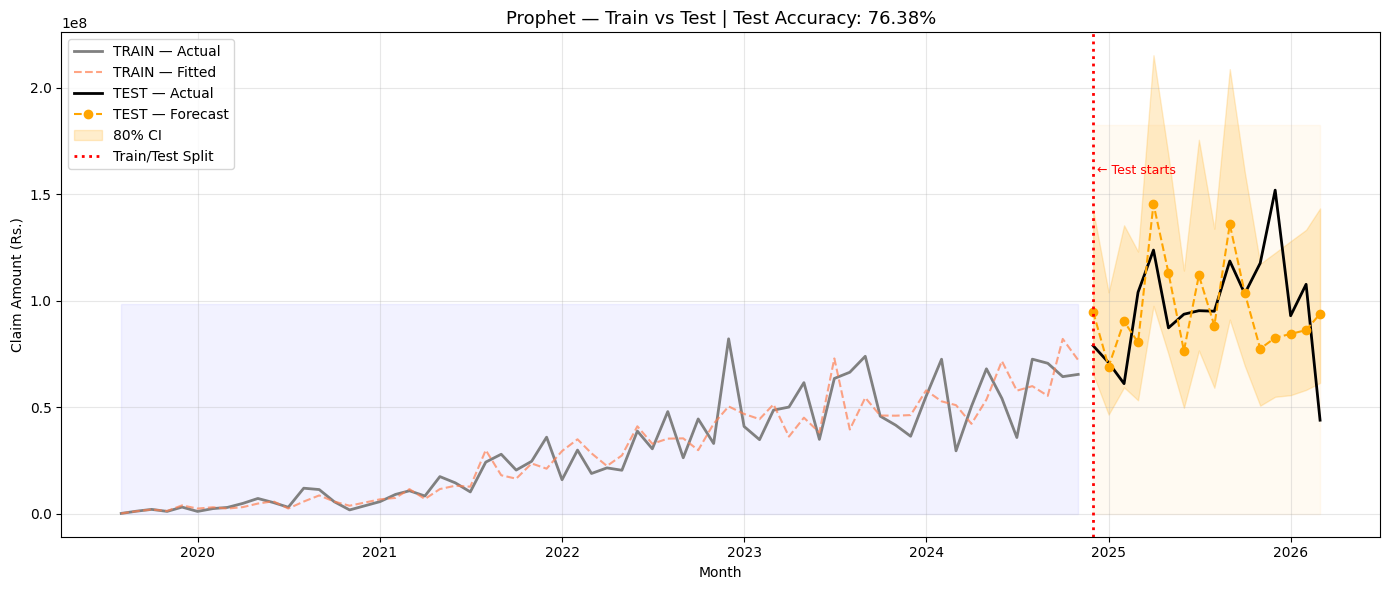

In [20]:
# ============================================================
# SECTION 18: MODEL B — PROPHET (with all regressors)
# ============================================================
print("\n" + "=" * 60)
print("  MODEL B: PROPHET (with all regressors)")
print("=" * 60)

prophet_df = ts_data.reset_index()[["claim_month", "total_claim_amount"] + REGRESSOR_COLS].copy()
prophet_df = prophet_df[prophet_df["total_claim_amount"] > 0]
prophet_df.rename(columns={"claim_month": "ds", "total_claim_amount": "y"}, inplace=True)
prophet_df["ds"] = pd.to_datetime(prophet_df["ds"])
prophet_df[REGRESSOR_COLS] = prophet_df[REGRESSOR_COLS].fillna(0)
prophet_df = prophet_df.dropna(subset=["y"]).sort_values("ds").reset_index(drop=True)

train_size_p     = int(len(prophet_df) * TRAIN_RATIO)
test_size_p      = len(prophet_df) - train_size_p
prophet_train_df = prophet_df.iloc[:train_size_p].copy()
prophet_test_df  = prophet_df.iloc[train_size_p:].copy()

# ─── TRAINING PHASE ───────────────────────────────────────────
print(f"\n  [PROPHET — TRAINING PHASE]")
print(f"  Training on {train_size_p} months: {prophet_train_df['ds'].iloc[0].strftime('%b %Y')} → {prophet_train_df['ds'].iloc[-1].strftime('%b %Y')}")

prophet_model = Prophet(
    changepoint_prior_scale=0.05,
    yearly_seasonality=False,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='additive',
    interval_width=0.80,
)
for col in REGRESSOR_COLS:
    prophet_model.add_regressor(col)
prophet_model.fit(prophet_train_df)

train_forecast  = prophet_model.predict(prophet_train_df)
p_train_preds   = np.expm1(train_forecast.set_index('ds')['yhat'])
p_train_actuals = np.expm1(prophet_train_df.set_index('ds')['y'])
p_train_mae     = np.mean(np.abs(p_train_actuals - p_train_preds))
p_train_wape    = (np.sum(np.abs(p_train_actuals - p_train_preds)) / np.sum(p_train_actuals)) * 100
p_train_acc     = max(0, 100 - p_train_wape)
print(f"  [PROPHET TRAINING] MAE: Rs.{p_train_mae:,.2f} | Accuracy: {p_train_acc:.2f}%")

# ─── TESTING PHASE ────────────────────────────────────────────
print(f"\n  [PROPHET — TESTING PHASE]")
print(f"  Testing on {test_size_p} months: {prophet_test_df['ds'].iloc[0].strftime('%b %Y')} → {prophet_test_df['ds'].iloc[-1].strftime('%b %Y')}")

test_forecast  = prophet_model.predict(prophet_test_df)
p_test_preds   = np.expm1(test_forecast.set_index('ds')['yhat'])
p_test_actuals = np.expm1(prophet_test_df.set_index('ds')['y'])
p_test_mae     = np.mean(np.abs(p_test_actuals - p_test_preds))
p_test_rmse    = np.sqrt(np.mean((p_test_actuals - p_test_preds) ** 2))
p_test_wape    = (np.sum(np.abs(p_test_actuals - p_test_preds)) / np.sum(p_test_actuals)) * 100
p_test_acc     = max(0, 100 - p_test_wape)

print(f"\n  [PROPHET TESTING RESULTS]")
print(f"  MAE      : Rs. {p_test_mae:,.2f}")
print(f"  RMSE     : Rs. {p_test_rmse:,.2f}")
print(f"  WAPE     : {p_test_wape:.2f}%")
print(f"  Accuracy : {p_test_acc:.2f}%")

# Prophet Plot — Train and Test clearly shown
plt.figure(figsize=(14, 6))
lower = np.expm1(test_forecast.set_index('ds')['yhat_lower'])
upper = np.expm1(test_forecast.set_index('ds')['yhat_upper'])
plt.fill_betweenx([0, p_train_actuals.max() * 1.2],
                  p_train_actuals.index[0], p_train_actuals.index[-1],
                  alpha=0.05, color='blue')
plt.fill_betweenx([0, p_test_actuals.max() * 1.2],
                  p_test_actuals.index[0], p_test_actuals.index[-1],
                  alpha=0.05, color='orange')
plt.plot(p_train_actuals.index, p_train_actuals.values, label="TRAIN — Actual",  color="gray",   linewidth=2)
plt.plot(p_train_preds.index,   p_train_preds.values,   label="TRAIN — Fitted",  color="coral",  linestyle="--", alpha=0.7)
plt.plot(p_test_actuals.index,  p_test_actuals.values,  label="TEST — Actual",   color="black",  linewidth=2)
plt.plot(p_test_preds.index,    p_test_preds.values,    label="TEST — Forecast", color="orange", linestyle="--", marker='o')
plt.fill_between(p_test_preds.index, lower, upper, color='orange', alpha=0.2, label="80% CI")
plt.axvline(x=prophet_test_df['ds'].iloc[0], color='red', linestyle=':', linewidth=2, label="Train/Test Split")
plt.text(prophet_test_df['ds'].iloc[0], p_test_actuals.max() * 1.05, ' ← Test starts', color='red', fontsize=9)
plt.legend(loc='upper left')
plt.title(f"Prophet — Train vs Test | Test Accuracy: {p_test_acc:.2f}%", fontsize=13)
plt.xlabel("Month"); plt.ylabel("Claim Amount (Rs.)")
plt.grid(True, alpha=0.3); plt.tight_layout()
plt.savefig(SAVE_DIR + "prophet_train_test.png", dpi=150)
plt.savefig(DRIVE_DIR + "/prophet_only_eval.png", dpi=150)
plt.show()


       MODEL COMPARISON: ARIMAX vs PROPHET
               Metric        ARIMAX       Prophet
Training Accuracy (%)         72.70         75.60
    Test Accuracy (%)         51.28         76.38
       Test MAE (Rs.) 47,078,588.09 22,825,436.31
      Test RMSE (Rs.) 52,886,549.86 28,659,068.57
        Test WAPE (%)         48.72         23.62

 BEST MODEL: Prophet (Test Accuracy: 76.38%)


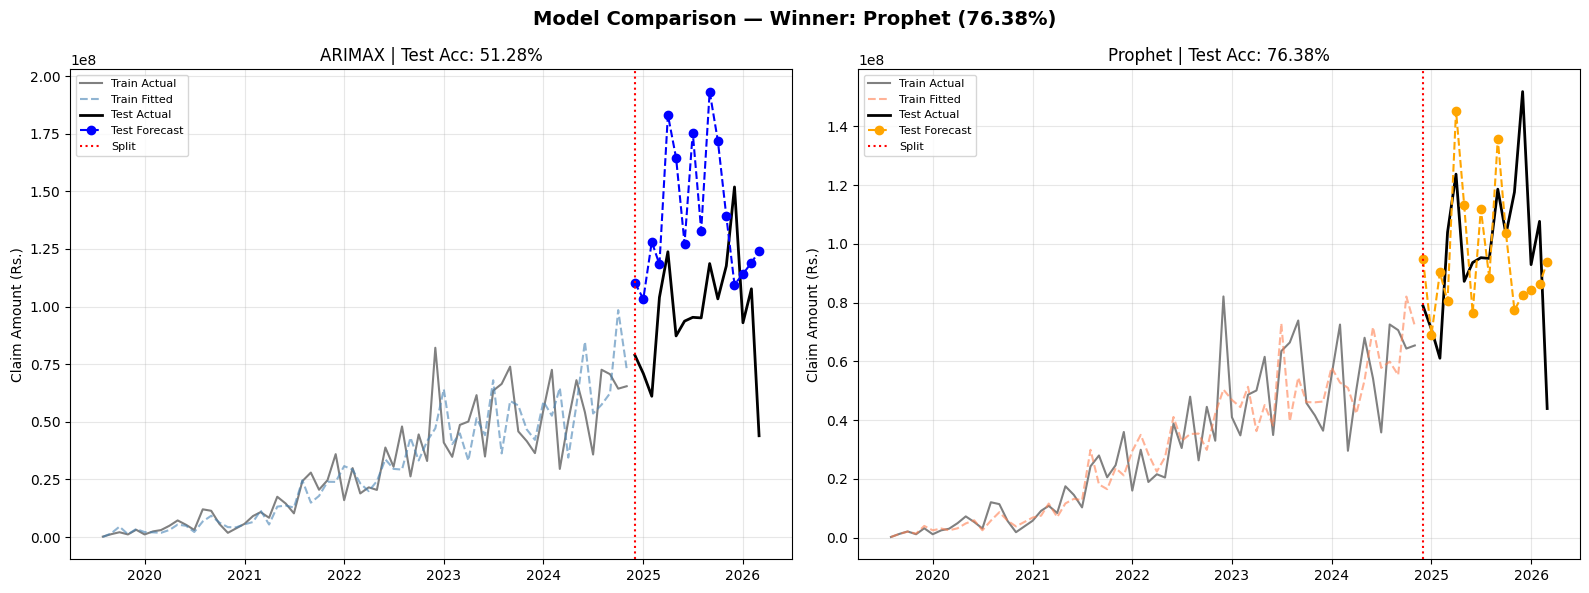

In [21]:
# ============================================================
# SECTION 19: MODEL COMPARISON
# ============================================================
print("\n" + "=" * 60)
print("       MODEL COMPARISON: ARIMAX vs PROPHET")
print("=" * 60)

comparison_df = pd.DataFrame({
    "Metric"  : ["Training Accuracy (%)", "Test Accuracy (%)", "Test MAE (Rs.)", "Test RMSE (Rs.)", "Test WAPE (%)"],
    "ARIMAX"  : [f"{arimax_train_acc:.2f}", f"{arimax_acc:.2f}",   f"{arimax_mae:,.2f}",  f"{arimax_rmse:,.2f}",  f"{arimax_wape:.2f}"],
    "Prophet" : [f"{p_train_acc:.2f}",     f"{p_test_acc:.2f}",   f"{p_test_mae:,.2f}",  f"{p_test_rmse:,.2f}",  f"{p_test_wape:.2f}"],
})
print(comparison_df.to_string(index=False))

if arimax_acc >= p_test_acc:
    winner = "ARIMAX"; winner_acc = arimax_acc
    print(f"\n BEST MODEL: ARIMAX  (Test Accuracy: {arimax_acc:.2f}%)")
else:
    winner = "Prophet"; winner_acc = p_test_acc
    print(f"\n BEST MODEL: Prophet (Test Accuracy: {p_test_acc:.2f}%)")
print("=" * 60)

# Side-by-side comparison plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(actuals_train_rs.index, actuals_train_rs.values, label="Train Actual", color="gray")
axes[0].plot(arimax_train_rs.index,  arimax_train_rs.values,  label="Train Fitted", color="steelblue", linestyle="--", alpha=0.6)
axes[0].plot(actuals_test_rs.index,  actuals_test_rs.values,  label="Test Actual",  color="black", linewidth=2)
axes[0].plot(arimax_test_rs.index,   arimax_test_rs.values,   label="Test Forecast",color="blue",  linestyle="--", marker='o')
axes[0].axvline(x=y_test.index[0], color='red', linestyle=':', label="Split")
axes[0].set_title(f"ARIMAX | Test Acc: {arimax_acc:.2f}%"); axes[0].set_ylabel("Claim Amount (Rs.)")
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

axes[1].plot(p_train_actuals.index, p_train_actuals.values, label="Train Actual", color="gray")
axes[1].plot(p_train_preds.index,   p_train_preds.values,   label="Train Fitted", color="coral",  linestyle="--", alpha=0.6)
axes[1].plot(p_test_actuals.index,  p_test_actuals.values,  label="Test Actual",  color="black",  linewidth=2)
axes[1].plot(p_test_preds.index,    p_test_preds.values,    label="Test Forecast",color="orange", linestyle="--", marker='o')
axes[1].axvline(x=prophet_test_df['ds'].iloc[0], color='red', linestyle=':', label="Split")
axes[1].set_title(f"Prophet | Test Acc: {p_test_acc:.2f}%"); axes[1].set_ylabel("Claim Amount (Rs.)")
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

plt.suptitle(f"Model Comparison — Winner: {winner} ({winner_acc:.2f}%)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_DIR + "model_comparison.png", dpi=150)
plt.savefig(DRIVE_DIR + "/model_comparison.png", dpi=150)
plt.show()

# Save accuracy JSON for app
with open(SAVE_DIR + "model_accuracy.json", "w") as f:
    json.dump({
        "winner": winner, "winner_accuracy": round(winner_acc, 2),
        "arima_accuracy": round(arimax_acc, 2), "prophet_accuracy": round(p_test_acc, 2),
        "arima_mae": round(arimax_mae, 2), "prophet_mae": round(p_test_mae, 2),
        "arima_rmse": round(arimax_rmse, 2), "prophet_rmse": round(p_test_rmse, 2),
        "arima_wape": round(arimax_wape, 2), "prophet_wape": round(p_test_wape, 2),
        "arima_train_acc": round(arimax_train_acc, 2), "prophet_train_acc": round(p_train_acc, 2),
    }, f, indent=2)

In [22]:
# ============================================================
# SECTION 20: RETRAIN WINNER ON FULL DATA
# ============================================================
print(f"\nRetraining {winner} on full dataset...")

if winner == "ARIMAX":
    arima_final = SARIMAX(y, exog=exog_scaled, order=(1, 1, 1),
                          enforce_stationarity=False, enforce_invertibility=False
                          ).fit(disp=False, maxiter=2000)
    pickle.dump(arima_final, open(SAVE_DIR + "best_model.pkl", "wb"))
else:
    prophet_final = Prophet(changepoint_prior_scale=0.05, yearly_seasonality=False,
                            weekly_seasonality=False, daily_seasonality=False,
                            seasonality_mode='additive', interval_width=0.80)
    for col in REGRESSOR_COLS:
        prophet_final.add_regressor(col)
    prophet_final.fit(prophet_df)
    pickle.dump(prophet_final, open(SAVE_DIR + "best_model.pkl", "wb"))

with open(SAVE_DIR + "best_model_type.txt", "w") as f:
    f.write(winner)
print(f"{winner} retrained on full data and saved.")


Retraining Prophet on full dataset...
Prophet retrained on full data and saved.



=== 3-MONTH FORECAST ===
     Month  Forecasted_Total_Claim_Amount (Rs.)
April 2026                         7.294209e+07
  May 2026                         6.003581e+07
 June 2026                         4.909345e+07


,Month,Forecasted_Total_Claim_Amount (Rs.)
0,April 2026,"Rs. 72,942,086.49"
1,May 2026,"Rs. 60,035,806.78"
2,June 2026,"Rs. 49,093,454.48"


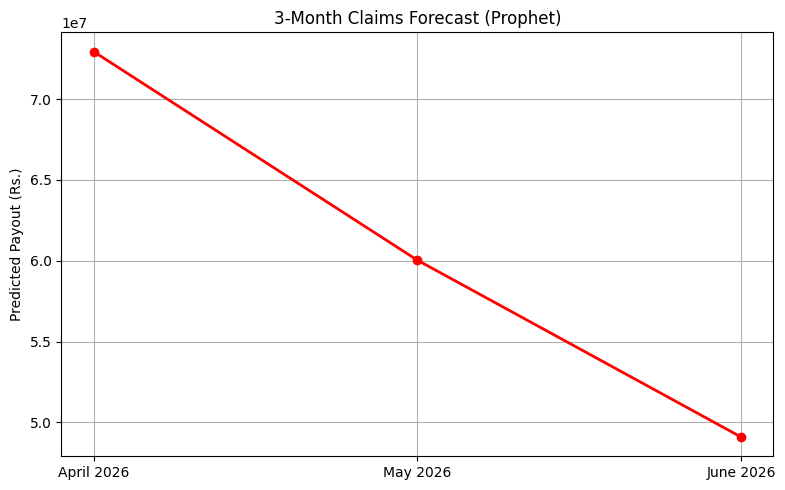

In [23]:
# ============================================================
# SECTION 21: 3-MONTH FORECAST
# ============================================================
future_steps = 3

if winner == "Prophet":
    last_known = prophet_df[REGRESSOR_COLS].iloc[-1]
    future_dates = pd.date_range(
        start=prophet_df["ds"].max() + pd.offsets.MonthBegin(1), periods=future_steps, freq='MS'
    )
    future_pred_df = pd.concat([
        pd.DataFrame({"ds": future_dates}),
        pd.DataFrame([last_known.values] * future_steps, columns=REGRESSOR_COLS)
    ], axis=1)
    future_forecast   = prophet_final.predict(future_pred_df)
    future_rs_payouts = np.expm1(future_forecast["yhat"].values)
else:
    last_exog = exog_scaled.iloc[[-1] * future_steps].values
    future_log        = arima_final.forecast(steps=future_steps, exog=last_exog)
    future_rs_payouts = np.expm1(future_log.values)
    future_dates      = pd.date_range(
        start=ts_data.index[-1] + pd.offsets.MonthBegin(1), periods=future_steps, freq='MS'
    )

future_df = pd.DataFrame({
    "Month": [d.strftime('%B %Y') for d in future_dates],
    "Forecasted_Total_Claim_Amount (Rs.)": future_rs_payouts
})
print("\n=== 3-MONTH FORECAST ===")
print(future_df.to_string(index=False))

from IPython.display import display
display(future_df.style.format({"Forecasted_Total_Claim_Amount (Rs.)": "Rs. {:,.2f}"}))

plt.figure(figsize=(8, 5))
plt.plot(future_df["Month"], future_rs_payouts, marker='o', color='red', linewidth=2)
plt.title(f"3-Month Claims Forecast ({winner})")
plt.ylabel("Predicted Payout (Rs.)"); plt.grid(True); plt.tight_layout()
plt.savefig(SAVE_DIR + "kpi_3month_forecast.png", dpi=150)
plt.show()


Explanation proxy MAE (log scale): 0.2956


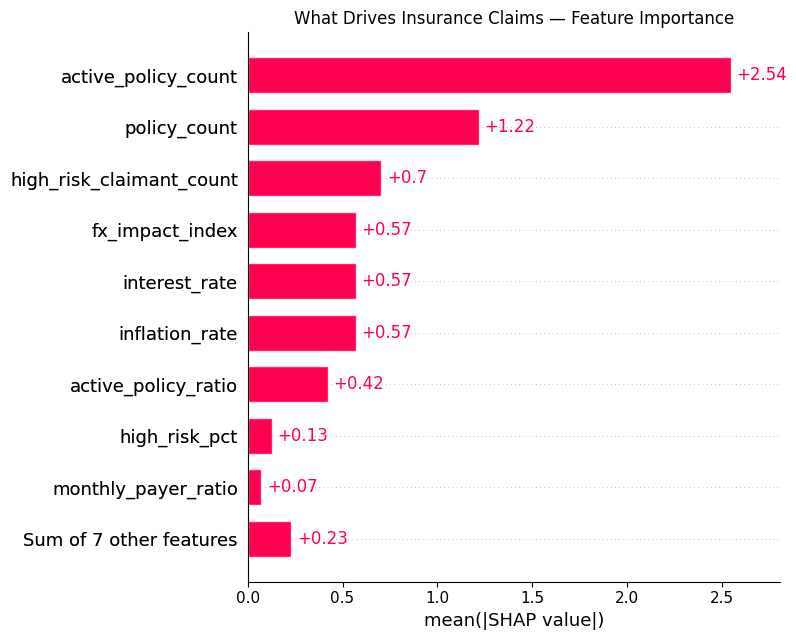

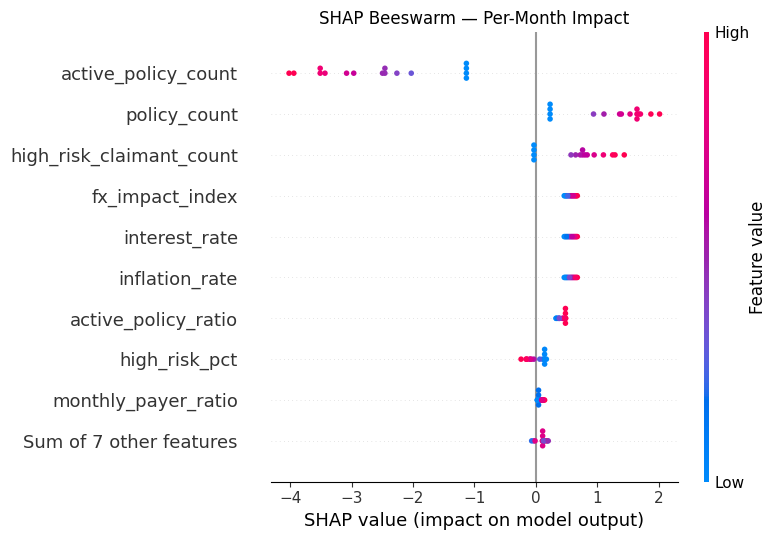

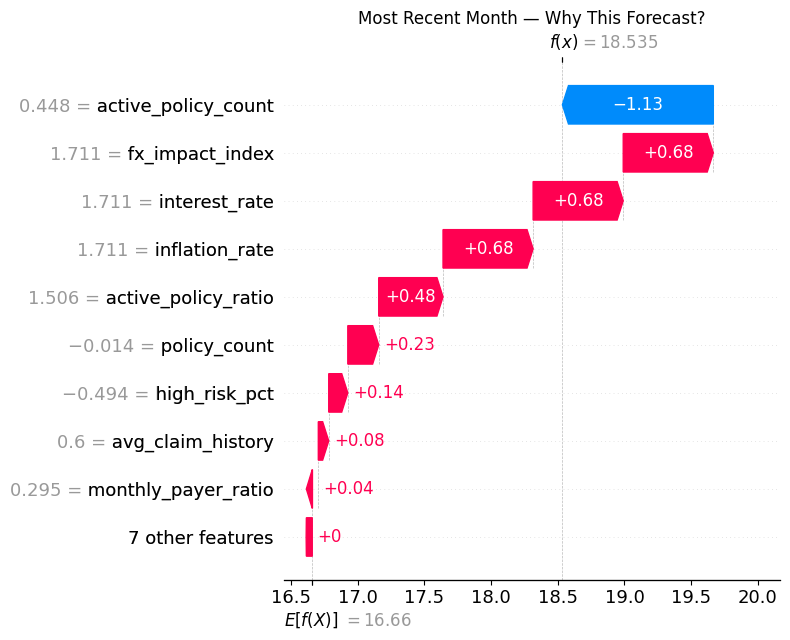

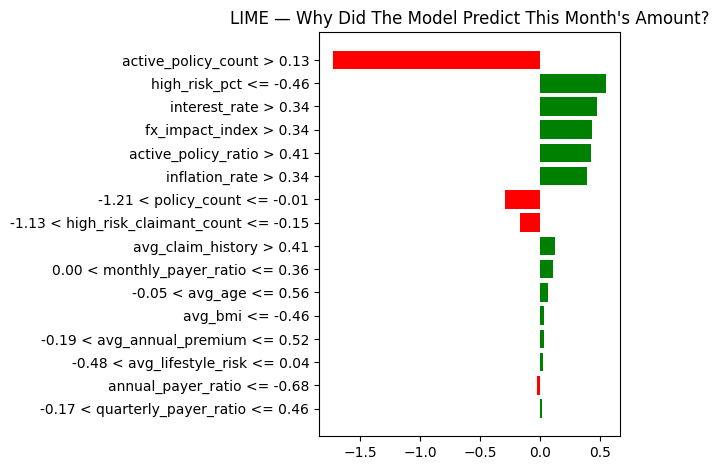


--- LIME EXPLANATION ---
  • active_policy_count > 0.13 → DECREASED the forecast by 1.7313
  • high_risk_pct <= -0.46 → INCREASED the forecast by 0.5548
  • interest_rate > 0.34 → INCREASED the forecast by 0.4800
  • fx_impact_index > 0.34 → INCREASED the forecast by 0.4333
  • active_policy_ratio > 0.41 → INCREASED the forecast by 0.4300
  • inflation_rate > 0.34 → INCREASED the forecast by 0.3899
  • -1.21 < policy_count <= -0.01 → DECREASED the forecast by 0.2887
  • -1.13 < high_risk_claimant_count <= -0.15 → DECREASED the forecast by 0.1706
  • avg_claim_history > 0.41 → INCREASED the forecast by 0.1224
  • 0.00 < monthly_payer_ratio <= 0.36 → INCREASED the forecast by 0.1118
  • -0.05 < avg_age <= 0.56 → INCREASED the forecast by 0.0703
  • avg_bmi <= -0.46 → INCREASED the forecast by 0.0316
  • -0.19 < avg_annual_premium <= 0.52 → INCREASED the forecast by 0.0301
  • -0.48 < avg_lifestyle_risk <= 0.04 → INCREASED the forecast by 0.0269
  • annual_payer_ratio <= -0.68 → DECREASE

In [24]:
# ============================================================
# SECTION 22: SHAP & LIME — EXPLAINABILITY
# ============================================================
import shap, lime, lime.lime_tabular

explain_df     = ts_data[REGRESSOR_COLS].fillna(0)
explain_target = ts_data['target_log'].fillna(0)
scaler_explain = StandardScaler()
X_explain      = scaler_explain.fit_transform(explain_df)

e_train_size = int(len(X_explain) * TRAIN_RATIO)
X_e_train, X_e_test = X_explain[:e_train_size], X_explain[e_train_size:]
y_e_train, y_e_test = explain_target.values[:e_train_size], explain_target.values[e_train_size:]

proxy = LinearRegression()
proxy.fit(X_e_train, y_e_train)
print(f"\nExplanation proxy MAE (log scale): {mean_absolute_error(y_e_test, proxy.predict(X_e_test)):.4f}")

# SHAP
explainer   = shap.LinearExplainer(proxy, X_e_train)
shap_values = explainer.shap_values(X_e_test)
shap_exp = shap.Explanation(values=shap_values, base_values=explainer.expected_value,
                             data=X_e_test, feature_names=REGRESSOR_COLS)

plt.figure(figsize=(8, 5))
shap.plots.bar(shap_exp, show=False)
plt.title("What Drives Insurance Claims — Feature Importance")
plt.tight_layout(); plt.savefig(SAVE_DIR + "shap_bar.png", dpi=150); plt.show()

plt.figure(figsize=(8, 5))
shap.plots.beeswarm(shap_exp, show=False)
plt.title("SHAP Beeswarm — Per-Month Impact")
plt.tight_layout(); plt.savefig(SAVE_DIR + "shap_beeswarm.png", dpi=150); plt.show()

plt.figure(figsize=(8, 5))
shap.plots.waterfall(shap_exp[-1], show=False)
plt.title("Most Recent Month — Why This Forecast?")
plt.tight_layout(); plt.savefig(SAVE_DIR + "shap_waterfall.png", dpi=150); plt.show()

# LIME
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_e_train, feature_names=REGRESSOR_COLS, mode="regression", verbose=False
)
lime_exp = lime_explainer.explain_instance(X_e_test[-1], proxy.predict, num_features=len(REGRESSOR_COLS))
fig = lime_exp.as_pyplot_figure()
plt.title("LIME — Why Did The Model Predict This Month's Amount?")
plt.tight_layout(); plt.savefig(SAVE_DIR + "lime_explanation.png", dpi=150); plt.show()

print("\n--- LIME EXPLANATION ---")
for feature, weight in lime_exp.as_list():
    direction = "INCREASED" if weight > 0 else "DECREASED"
    print(f"  • {feature} → {direction} the forecast by {abs(weight):.4f}")


In [25]:
# ============================================================
# SECTION 23: KPI DASHBOARD
# ============================================================
print("\nGENERATING KPI DASHBOARD")

# ------------------------------------------------------------
# 1) Build a policy-level premium base
#    Drop duplicate policies so premium is not repeated across claim rows
# ------------------------------------------------------------
policy_base = (
    df.sort_values("claim_settled_date")
      .drop_duplicates("policy_id")
      .copy()
)

# If Premium is an installment, annual_premium should be Premium * periods
policy_base["annual_premium_calc"] = policy_base["Premium"] * policy_base["payment_periods_per_year"]

# Prefer annual_premium if it is valid, otherwise fallback
policy_base["premium_used"] = policy_base["annual_premium"].where(
    policy_base["annual_premium"].notna() & (policy_base["annual_premium"] > 0),
    policy_base["annual_premium_calc"]
)

policy_base = policy_base[policy_base["premium_used"] > 0]

print("\n=== Premium Sanity Check ===")
print(policy_base[["Premium", "payment_periods_per_year", "annual_premium", "annual_premium_calc", "premium_used"]].describe())

# ------------------------------------------------------------
# 2) Claims paid
# ------------------------------------------------------------
claims_paid = df.groupby("claim_id")["PaidAmount_x"].sum().sum()

# ------------------------------------------------------------
# 3) Period-adjusted premium
# ------------------------------------------------------------
months_covered = df["claim_month"].nunique()
years_covered = months_covered / 12

total_premium_annual = policy_base["premium_used"].sum()
earned_premium_period = total_premium_annual * years_covered

# ------------------------------------------------------------
# 4) Loss ratio
# ------------------------------------------------------------
loss_ratio = (claims_paid / earned_premium_period) * 100

# ------------------------------------------------------------
# 5) Closure rate on unique policies
# ------------------------------------------------------------
policy_status_df = df.drop_duplicates("policy_id")[["policy_id", "is_active_policy"]]
closed_policies = (policy_status_df["is_active_policy"] == 0).sum()
closure_rate = (closed_policies / len(policy_status_df)) * 100

# ------------------------------------------------------------
# 6) High-risk share
# ------------------------------------------------------------
high_risk_claims = df.loc[df["risk_bucket"] == "High", "PaidAmount_x"].sum()
high_risk_share = (high_risk_claims / claims_paid) * 100

print(f"Loss Ratio (period-adjusted) : {loss_ratio:.2f}%")
print(f"Claims Paid                  : Rs.{claims_paid:,.0f}")
print(f"Earned Premium (period)      : Rs.{earned_premium_period:,.0f}")
print(f"Closure Rate                 : {closure_rate:.2f}%")
print(f"High Risk Claim Share        : {high_risk_share:.2f}%")


GENERATING KPI DASHBOARD

=== Premium Sanity Check ===
             Premium  payment_periods_per_year  annual_premium  \
count    2445.000000               2445.000000    2.445000e+03   
mean     2939.634470                  8.397710    5.433242e+04   
std      7483.335555                  4.903176    1.111239e+05   
min         0.000000                  1.000000    0.000000e+00   
25%       315.000000                  2.000000    6.900000e+03   
50%       742.140000                 12.000000    1.420200e+04   
75%      2253.130000                 12.000000    4.508600e+04   
max    175153.340000                 12.000000    1.499789e+06   

       annual_premium_calc  premium_used  
count          2445.000000  2.445000e+03  
mean           9072.433898  5.433307e+04  
std           12862.415825  1.111236e+05  
min               0.000000  7.875000e+02  
25%            2160.000000  6.900000e+03  
50%            4536.000000  1.420200e+04  
75%            9450.000000  4.508600e+04  
max  

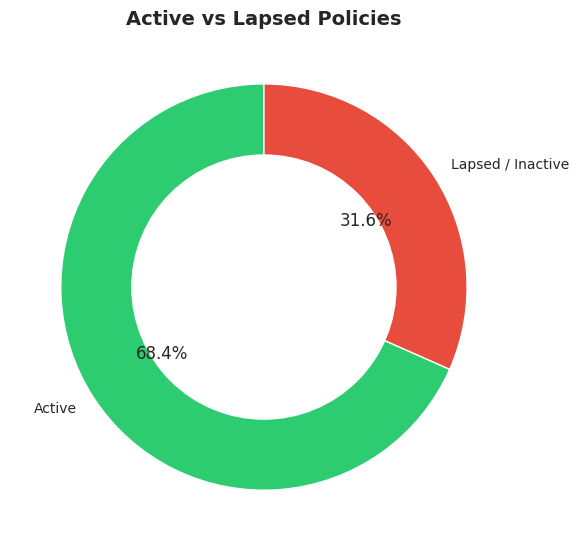

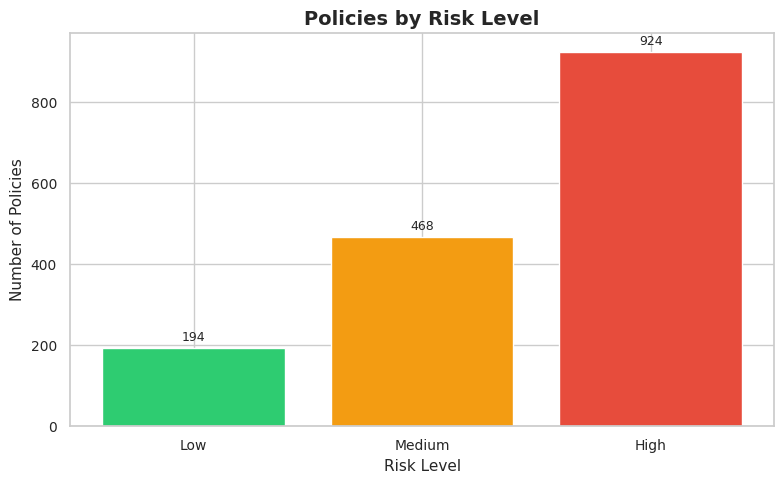

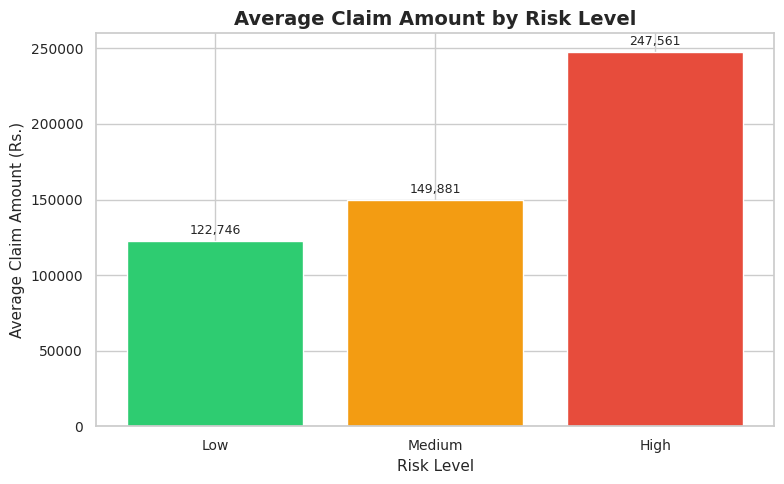

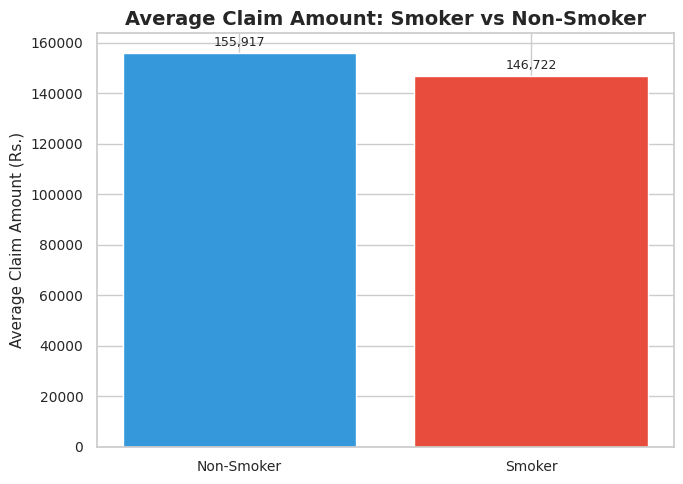

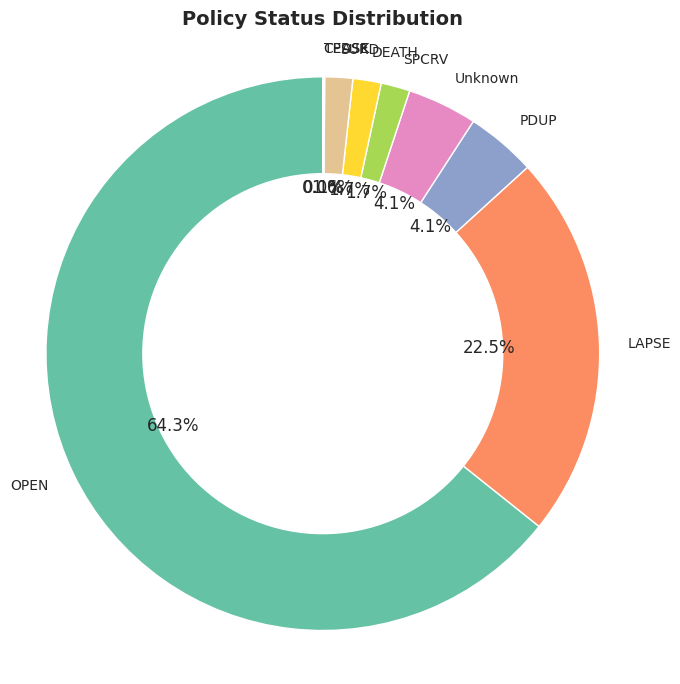

/tmp/ipykernel_15318/2122012560.py:153: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="payment_freq_label", order=freq_order, palette="viridis")


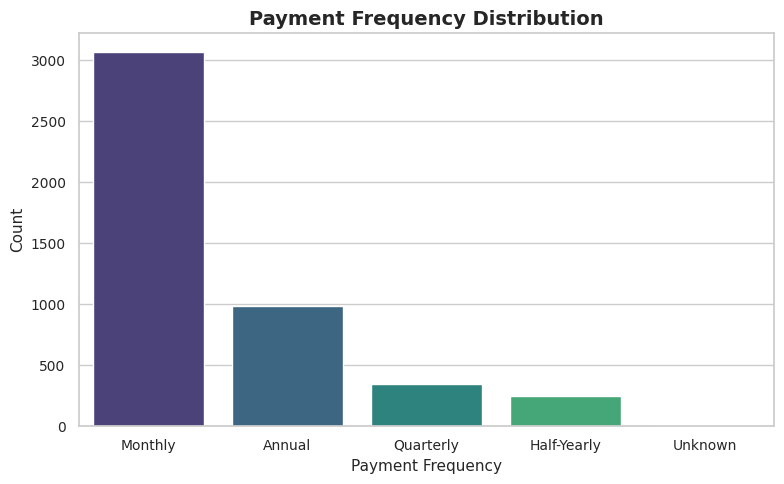

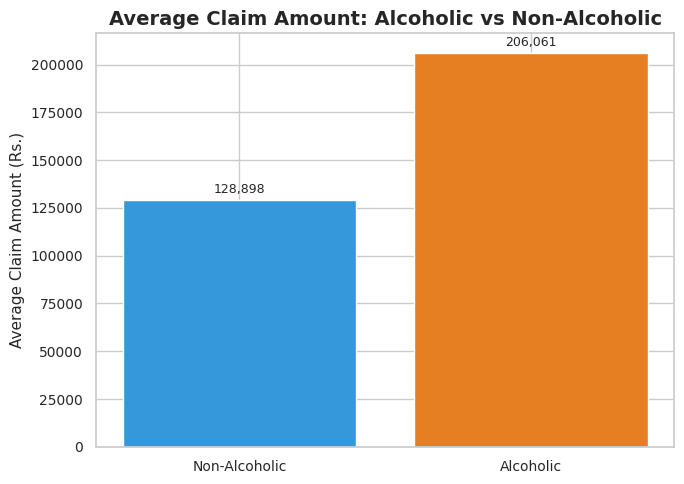

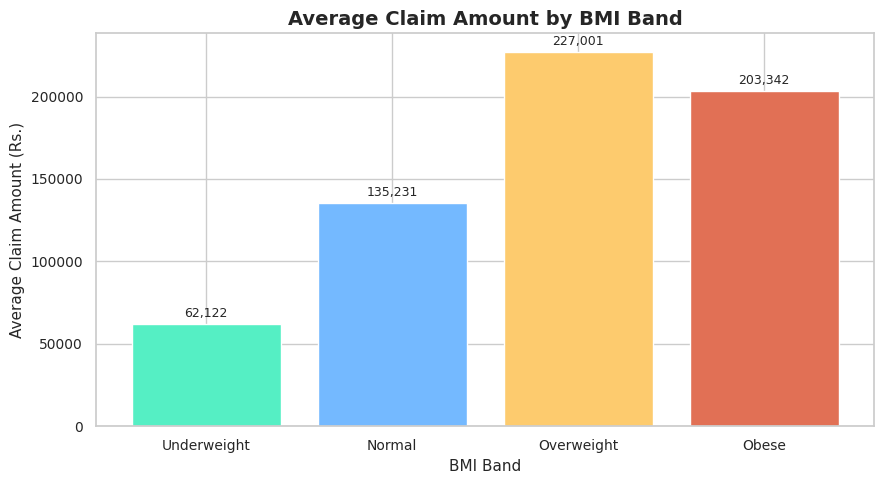

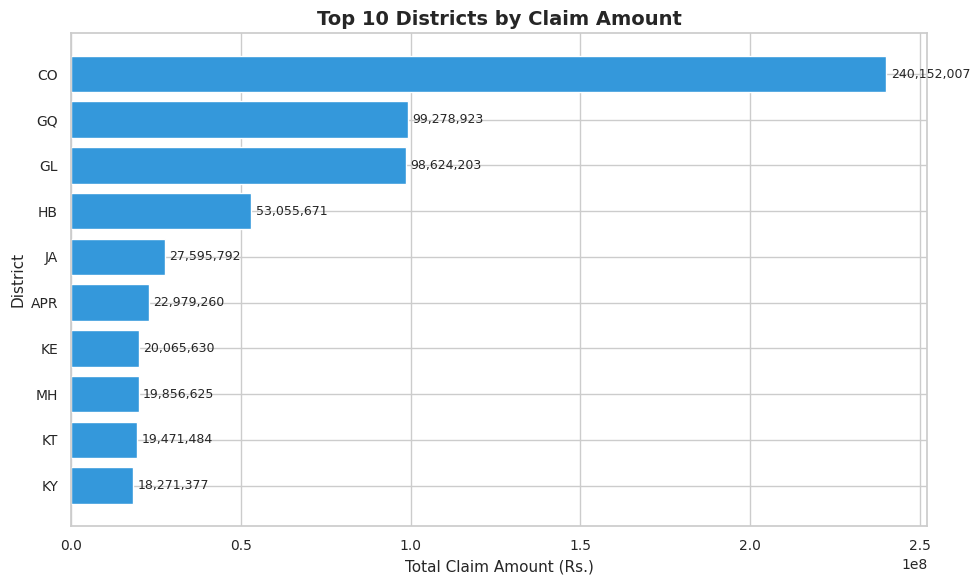

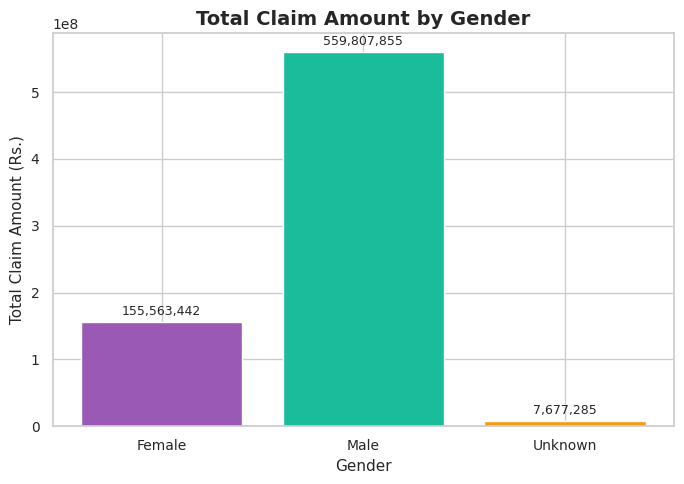

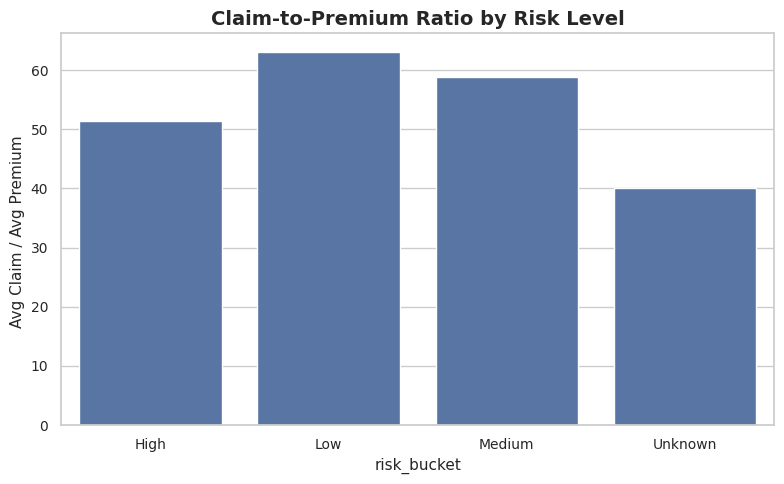

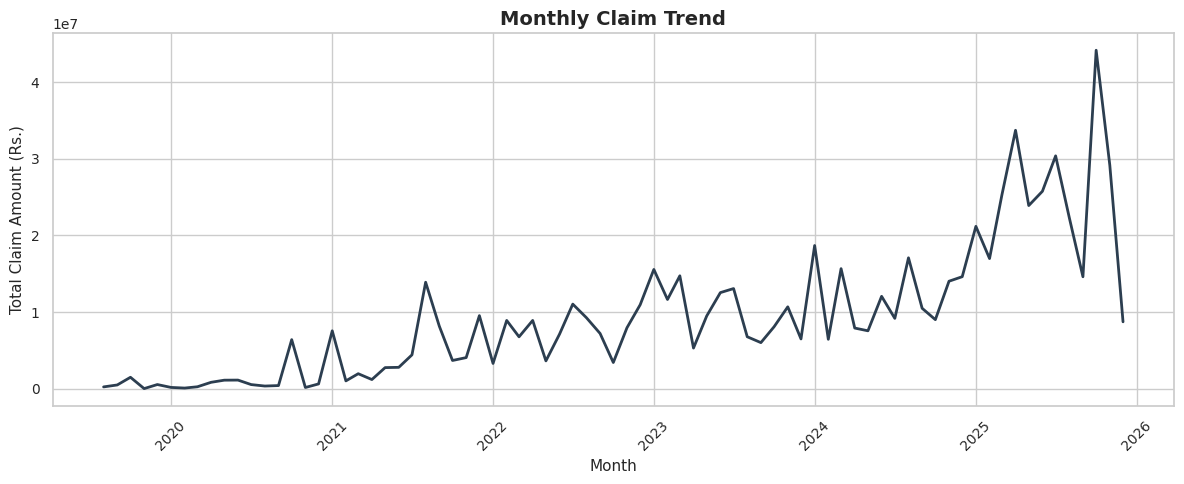


Saved 12 simple UI plots to: /content/drive/MyDrive/SDGP/ui_simple
Manifest saved as plot_manifest.json


In [26]:
# ============================================================
# UI VISUALIZATIONS
# ============================================================

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

UI_DIR = os.path.join(DRIVE_DIR, "ui_simple")
os.makedirs(UI_DIR, exist_ok=True)

plot_manifest = []

def save_show(filename, title):
    plt.title(title)
    plt.tight_layout()
    plt.savefig(os.path.join(UI_DIR, filename), dpi=180, bbox_inches="tight")
    plt.show()
    plt.close()
    plot_manifest.append({"file": filename, "title": title})

def add_labels(ax, fmt="{:,.0f}"):
    for c in ax.containers:
        ax.bar_label(c, labels=[fmt.format(v) for v in c.datavalues], padding=3, fontsize=9)

# ============================================================
# Build a simple policy-level table for "health -> profit" story
# ============================================================
agg_dict = {
    "annual_premium": ("annual_premium", "mean"),
    "total_claims": ("PaidAmount_x", "sum"),
    "BMI": ("BMI", "mean"),
    "IsSmoker": ("IsSmoker", "max"),
    "IsAlcoholic": ("IsAlcoholic", "max"),
    "risk_bucket": ("risk_bucket", "first"),
    "policy_status": ("policy_status", "first"),
}
if "District" in df.columns:
    agg_dict["District"] = ("District", "first")
if "Gender" in df.columns:
    agg_dict["Gender"] = ("Gender", "first")

policy_profit = df.groupby("policy_id").agg(**agg_dict).reset_index()
policy_profit["profit_proxy"] = policy_profit["annual_premium"] - policy_profit["total_claims"]

# Simple health score for UI
policy_profit["health_score"] = 100
policy_profit.loc[policy_profit["IsSmoker"] == 1, "health_score"] -= 35
policy_profit.loc[policy_profit["IsAlcoholic"] == 1, "health_score"] -= 25
policy_profit.loc[policy_profit["BMI"] >= 25, "health_score"] -= 10
policy_profit.loc[policy_profit["BMI"] >= 30, "health_score"] -= 10

policy_profit["health_band"] = pd.cut(
    policy_profit["health_score"],
    bins=[-1, 59, 79, 100],
    labels=["Low Health", "Medium Health", "High Health"]
)

policy_profit["bmi_band"] = pd.cut(
    policy_profit["BMI"],
    bins=[0, 18.5, 25, 30, 100],
    labels=["Underweight", "Normal", "Overweight", "Obese"],
    include_lowest=True
)

# ============================================================
# 1) Active vs Lapsed policies
# ============================================================
active_count = int(df["is_active_policy"].sum())
inactive_count = int(len(df) - active_count)

plt.figure(figsize=(6, 6))
vals = [active_count, inactive_count]
labels = ["Active", "Lapsed / Inactive"]
colors = ["#2ecc71", "#e74c3c"]
plt.pie(vals, labels=labels, autopct="%1.1f%%", startangle=90, colors=colors)
centre_circle = plt.Circle((0, 0), 0.65, fc="white")
plt.gca().add_artist(centre_circle)
save_show("active_vs_lapsed.png", "Active vs Lapsed Policies")

# ============================================================
# 2) Policies by risk level
# ============================================================
if "risk_bucket" in df.columns:
    risk_order = [x for x in ["Low", "Medium", "High"] if x in df["risk_bucket"].dropna().unique()]
    risk_counts = df["risk_bucket"].value_counts().reindex(risk_order)

    plt.figure(figsize=(8, 5))
    bars = plt.bar(risk_counts.index, risk_counts.values, color=["#2ecc71", "#f39c12", "#e74c3c"][:len(risk_counts)])
    add_labels(plt.gca())
    plt.xlabel("Risk Level")
    plt.ylabel("Number of Policies")
    save_show("risk_bucket_count.png", "Policies by Risk Level")

# ============================================================
# 3) Average claim by risk level
# ============================================================
if "risk_bucket" in df.columns:
    avg_claim_by_risk = df.groupby("risk_bucket")["PaidAmount_x"].mean()
    avg_claim_by_risk = avg_claim_by_risk.reindex(risk_order)

    plt.figure(figsize=(8, 5))
    bars = plt.bar(avg_claim_by_risk.index, avg_claim_by_risk.values, color=["#2ecc71", "#f39c12", "#e74c3c"][:len(avg_claim_by_risk)])
    add_labels(plt.gca())
    plt.xlabel("Risk Level")
    plt.ylabel("Average Claim Amount (Rs.)")
    save_show("avg_claim_by_risk.png", "Average Claim Amount by Risk Level")

# ============================================================
# 4) Claim amount: smoker vs non-smoker
# ============================================================
if "IsSmoker" in df.columns:
    smoke_df = df.copy()
    smoke_df["smoker_status"] = smoke_df["IsSmoker"].replace({1: "Smoker", 0: "Non-Smoker"})
    smoke_claim = smoke_df.groupby("smoker_status")["PaidAmount_x"].mean().reindex(["Non-Smoker", "Smoker"])

    plt.figure(figsize=(7, 5))
    bars = plt.bar(smoke_claim.index, smoke_claim.values, color=["#3498db", "#e74c3c"])
    add_labels(plt.gca())
    plt.xlabel("")
    plt.ylabel("Average Claim Amount (Rs.)")
    save_show("claim_by_smoker.png", "Average Claim Amount: Smoker vs Non-Smoker")


if "policy_status" in df.columns:
    status_counts = df["policy_status"].value_counts()
    plt.figure(figsize=(7, 7))
    wedges, texts, autotexts = plt.pie(
        status_counts.values,
        labels=status_counts.index,
        autopct="%1.1f%%",
        startangle=90,
        colors=sns.color_palette("Set2", len(status_counts))
    )
    centre_circle = plt.Circle((0, 0), 0.65, fc="white")
    fig = plt.gcf()
    fig.gca().add_artist(centre_circle)
    plt.axis("equal")
    save_show("policy_status_donut.png", "Policy Status Distribution")

# ------------------------------------------------------------
# 5) Payment frequency distribution
# ------------------------------------------------------------
if "payment_freq_label" in df.columns:
    plt.figure(figsize=(8, 5))
    freq_order = df["payment_freq_label"].value_counts().index
    sns.countplot(data=df, x="payment_freq_label", order=freq_order, palette="viridis")
    plt.xlabel("Payment Frequency")
    plt.ylabel("Count")
    save_show("payment_frequency_distribution.png", "Payment Frequency Distribution")



# ============================================================
# 5) Claim amount: alcoholic vs non-alcoholic
# ============================================================
if "IsAlcoholic" in df.columns:
    alcohol_df = df.copy()
    alcohol_df["alcohol_status"] = alcohol_df["IsAlcoholic"].replace({1: "Alcoholic", 0: "Non-Alcoholic"})
    alcohol_claim = alcohol_df.groupby("alcohol_status")["PaidAmount_x"].mean().reindex(["Non-Alcoholic", "Alcoholic"])

    plt.figure(figsize=(7, 5))
    bars = plt.bar(alcohol_claim.index, alcohol_claim.values, color=["#3498db", "#e67e22"])
    add_labels(plt.gca())
    plt.xlabel("")
    plt.ylabel("Average Claim Amount (Rs.)")
    save_show("claim_by_alcohol.png", "Average Claim Amount: Alcoholic vs Non-Alcoholic")

# ============================================================
# 6) Claim amount by BMI band
# ============================================================
if "BMI" in df.columns:
    # Create bmi_band directly in df for this plot
    df["bmi_band"] = pd.cut(
        df["BMI"],
        bins=[0, 18.5, 25, 30, 100],
        labels=["Underweight", "Normal", "Overweight", "Obese"],
        include_lowest=True
    )
    bmi_claim = df.groupby("bmi_band", observed=False)["PaidAmount_x"].mean()

    plt.figure(figsize=(9, 5))
    bars = plt.bar(bmi_claim.index.astype(str), bmi_claim.values, color=["#55efc4", "#74b9ff", "#fdcb6e", "#e17055"])
    add_labels(plt.gca())
    plt.xlabel("BMI Band")
    plt.ylabel("Average Claim Amount (Rs.)")
    save_show("claim_by_bmi_band.png", "Average Claim Amount by BMI Band")

# ============================================================
# 7) Top 10 districts by claim amount
# ============================================================
if "District" in df.columns:
    district_claims = df.groupby("District")["PaidAmount_x"].sum().sort_values(ascending=False).head(10)

    plt.figure(figsize=(10, 6))
    plt.barh(district_claims.index[::-1], district_claims.values[::-1], color="#3498db")
    add_labels(plt.gca())
    plt.xlabel("Total Claim Amount (Rs.)")
    plt.ylabel("District")
    save_show("top_district_claims.png", "Top 10 Districts by Claim Amount")

# ============================================================
# 8) Gender-wise total claim amount
# ============================================================
if "Gender" in df.columns:
    gender_claims = df.groupby("Gender")["PaidAmount_x"].sum()

    plt.figure(figsize=(7, 5))
    bars = plt.bar(gender_claims.index.astype(str), gender_claims.values, color=["#9b59b6", "#1abc9c", "#f39c12"])
    add_labels(plt.gca())
    plt.xlabel("Gender")
    plt.ylabel("Total Claim Amount (Rs.)")
    save_show("gender_claims.png", "Total Claim Amount by Gender")

# ============================================================
# 9) Health band vs profit proxy
#     This is the key chart for your story:
#     better health -> lower claims -> higher profit proxy
# ============================================================
# The previous implementation of this plot used 'axes[0, 1]' which implies a multi-subplot setup
# that is not initialized in this cell. To make it consistent with other plots in this section
# (which are standalone figures), we will create a new figure for this plot.

# B: Claim to Premium Ratio by risk
ratio_data = df.groupby('risk_bucket').agg(
    avg_premium=('Premium', 'mean'),
    avg_claim=('PaidAmount_x', 'mean')
).reset_index()
ratio_data['ratio'] = ratio_data['avg_claim'] / ratio_data['avg_premium']

plt.figure(figsize=(8, 5))
sns.barplot(x='risk_bucket', y='ratio', data=ratio_data) # Removed 'ax' argument
plt.title("Claim-to-Premium Ratio by Risk Level") # Changed from axes[0, 1].set_title
plt.ylabel("Avg Claim / Avg Premium ") # Changed from axes[0, 1].set_ylabel
save_show("claim_to_premium_ratio.png", "Claim-to-Premium Ratio by Risk Level")

# ============================================================
# 10) Monthly claim trend
# ============================================================
monthly_trend = df.groupby("claim_month").agg(
    total_claim=("PaidAmount_x", "sum"),
    policy_count=("policy_id", "nunique")
).reset_index()

plt.figure(figsize=(12, 5))
plt.plot(monthly_trend["claim_month"], monthly_trend["total_claim"], color="#2c3e50", linewidth=2)
plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("Total Claim Amount (Rs.)")
save_show("monthly_claim_trend.png", "Monthly Claim Trend")

# ============================================================
# Save manifest for UI
# ============================================================
with open(os.path.join(UI_DIR, "plot_manifest.json"), "w") as f:
    json.dump(plot_manifest, f, indent=2)

print(f"\nSaved {len(plot_manifest)} simple UI plots to: {UI_DIR}")
print("Manifest saved as plot_manifest.json")

In [27]:
#============================================================
# SECTION 24: SAVE ALL FILES TO GOOGLE DRIVE
# ============================================================
import shutil

# Models
pickle.dump(arimax_results, open(f"{DRIVE_DIR}/arimax_model.pkl",  "wb"))
pickle.dump(prophet_model,  open(f"{DRIVE_DIR}/prophet_model.pkl", "wb"))
pickle.dump(arima_final if winner == "ARIMAX" else prophet_final,
            open(f"{DRIVE_DIR}/best_model.pkl", "wb"))
with open(f"{DRIVE_DIR}/best_model_type.txt", "w") as f:
    f.write(winner)

# Accuracy metrics
with open(f"{DRIVE_DIR}/model_accuracy.json", "w") as f:
    json.dump({
        "winner": winner, "winner_accuracy": round(winner_acc, 2),
        "arima_accuracy": round(arimax_acc, 2), "prophet_accuracy": round(p_test_acc, 2),
        "arima_mae": round(arimax_mae, 2), "prophet_mae": round(p_test_mae, 2),
        "arima_rmse": round(arimax_rmse, 2), "prophet_rmse": round(p_test_rmse, 2),
        "arima_wape": round(arimax_wape, 2), "prophet_wape": round(p_test_wape, 2),
        "arima_train_acc": round(arimax_train_acc, 2), "prophet_train_acc": round(p_train_acc, 2),
        "regressors_used": REGRESSOR_COLS,
    }, f, indent=2)

# Scalers
joblib.dump(scaler,         f"{DRIVE_DIR}/scaler.joblib")
joblib.dump(scaler_exog,    f"{DRIVE_DIR}/scaler_exog.joblib")
joblib.dump(scaler_explain, f"{DRIVE_DIR}/scaler_explain.joblib")

# KPI CSVs
monthly_claims_export = monthly_actual_claims[
    ['claim_month','total_claim_amount_original_scale','total_claim_amount']].copy()
monthly_claims_export['claim_month'] = monthly_claims_export['claim_month'].astype(str)
monthly_claims_export.to_csv(f"{DRIVE_DIR}/kpi_monthly_claims.csv", index=False)

monthly_features_export = monthly_features.copy()
monthly_features_export['claim_month'] = monthly_features_export['claim_month'].astype(str)
monthly_features_export.to_csv(f"{DRIVE_DIR}/kpi_monthly_features.csv", index=False)

risk_claim = df.groupby('risk_bucket').agg(
    avg_claim=('final_claim_amount','mean'), median_claim=('final_claim_amount','median'),
    count=('final_claim_amount','count'),
    q25=('final_claim_amount', lambda x: x.quantile(0.25)),
    q75=('final_claim_amount', lambda x: x.quantile(0.75)),
    min_claim=('final_claim_amount','min'), max_claim=('final_claim_amount','max'),
).reset_index()
risk_claim.to_csv(f"{DRIVE_DIR}/kpi_risk_vs_claim.csv", index=False)

policy_status_counts = df['policy_status'].value_counts().reset_index()
policy_status_counts.columns = ['status', 'count']
policy_status_counts.to_csv(f"{DRIVE_DIR}/kpi_policy_status.csv", index=False)

smoker_pct = (df['IsSmoker'].sum() / len(df)) * 100
alcohol_pct = (df['IsAlcoholic'].sum() / len(df)) * 100

portfolio_stats = {
    "smoker_pct": round(smoker_pct, 2), "alcoholic_pct": round(alcohol_pct, 2),
    "avg_bmi": round(df['BMI'].mean(), 2), "avg_age": round(df['Age'].mean(), 2),
    "avg_annual_premium": round(df['annual_premium'].mean(), 2),
    "total_policies": int(df['policy_id'].nunique()),
    "total_claims": int(df['claim_id'].nunique()),
    "active_pct": round(df['is_active_policy'].mean() * 100, 2),
    "lapse_pct": round((1 - df['is_active_policy'].mean()) * 100, 2),
    "high_risk_pct": round((df['risk_bucket'] == 'High').mean() * 100, 2),
    "loss_ratio": round(loss_ratio, 2),
}
with open(f"{DRIVE_DIR}/kpi_portfolio_stats.json", "w") as f:
    json.dump(portfolio_stats, f, indent=2)

risk_trend_export = monthly_risk_trend.copy()
risk_trend_export['claim_month'] = risk_trend_export['claim_month'].astype(str)
risk_trend_export.to_csv(f"{DRIVE_DIR}/kpi_risk_trend.csv", index=False)

profit_by_risk = df.groupby('risk_bucket').agg(
    avg_annual_premium=('annual_premium','mean'), avg_claim=('PaidAmount_x','mean'), count=('policy_id','count'),
).reset_index()
profit_by_risk['claim_to_premium_ratio'] = round(profit_by_risk['avg_claim'] / profit_by_risk['avg_annual_premium'], 2)
profit_by_risk.to_csv(f"{DRIVE_DIR}/kpi_profit_by_risk.csv", index=False)

arima_eval = pd.DataFrame({
    'date': actuals_test_rs.index.astype(str),
    'actual': actuals_test_rs.values, 'predicted': arimax_test_rs.values,
})
arima_eval.to_csv(f"{DRIVE_DIR}/kpi_arima_eval.csv", index=False)

prophet_eval = pd.DataFrame({
    'date': p_test_actuals.index.astype(str),
    'actual': p_test_actuals.values, 'predicted': p_test_preds.values,
})
prophet_eval.to_csv(f"{DRIVE_DIR}/kpi_prophet_eval.csv", index=False)

future_df['Month_str'] = future_df['Month']
future_df.to_csv(f"{DRIVE_DIR}/kpi_3month_forecast.csv", index=False)

shap_importance = pd.DataFrame({
    'feature': REGRESSOR_COLS,
    'importance': np.abs(shap_values).mean(axis=0),
    'mean_shap': shap_values.mean(axis=0),
}).sort_values('importance', ascending=False)
shap_importance.to_csv(f"{DRIVE_DIR}/kpi_shap_importance.csv", index=False)

corr_export.to_csv(f"{DRIVE_DIR}/kpi_correlation.csv", index=False)

# Zip everything
shutil.make_archive('/content/model_exports', 'zip', DRIVE_DIR)

print("\n=== ALL FILES SAVED TO GOOGLE DRIVE ===")
for fname in sorted(os.listdir(DRIVE_DIR)):
    size = os.path.getsize(f"{DRIVE_DIR}/{fname}")
    print(f"  {fname:45s} ({size:,} bytes)")

print(f"\n✔ Winner          : {winner}")
print(f"✔ Test Accuracy   : {winner_acc:.2f}%")
print(f"✔ Time series     : {len(ts_data)} months")
print(f"✔ Regressors used : {len(REGRESSOR_COLS)}")
print(f"✔ Training months : {train_size}")
print(f"✔ Testing months  : {test_size}")


=== ALL FILES SAVED TO GOOGLE DRIVE ===
  Dataset2.xlsx                                 (480,515 bytes)
  Final Thesis (1).docx                         (7,882,540 bytes)
  all_models_comparison.png                     (93,665 bytes)
  arima_forecast.png                            (79,365 bytes)
  arimax_forecast.png                           (168,733 bytes)
  arimax_model.pkl                              (223,226 bytes)
  best_model.pkl                                (30,338 bytes)
  best_model_scaler.joblib                      (1,231 bytes)
  best_model_type.txt                           (7 bytes)
  combined_df.xlsx                              (1,197,710 bytes)
  dataset1.xlsx                                 (30,083 bytes)
  dataset3.xlsx                                 (479,256 bytes)
  dataset4.xlsx                                 (57,844 bytes)
  ensemble_forecast.png                         (103,052 bytes)
  exog_cols.json                                (167 bytes)
  final.xlsx

In [28]:
import joblib
# Save the ARIMAX results object
with open(f"{DRIVE_DIR}/arimax_model.pkl", "wb") as f:
    pickle.dump(arimax_results, f)

# Save the Prophet model
with open(f"{DRIVE_DIR}/prophet_model.pkl", "wb") as f:
    pickle.dump(prophet_model, f)

# Save the Scaler (Crucial for the 16 regressors)
joblib.dump(scaler_exog, f"{DRIVE_DIR}/scaler_exog.joblib")

['/content/drive/MyDrive/SDGP/scaler_exog.joblib']